# Single-contact spike detection (Real Data, CH19)
**The Goal** is to detect the firing of one known nerve fibre in a real rat saphenous nerve recording. This notebook only experiments on one channel, which is channel19. 
**The ground truth**: the lab marked 1,623 spikes for this unit. Here, the detections were tested against those markes. 
**The code difficulty encountered in this notebook in five ways:** the electrode picks up many fibres at once, so on a single channel  its diffecult to tell which fibre a given spike came from.
## Notebook Order


# Glossary 
## Windows
| Window | Code | What is measures | Between |
|----|----|----|----|
| 3 ms refractory | 'distance=90' | minimum gap so one spike is not counted twice | detection <-> detection|
| +/-2ms tolerance (field standard) | 'tolerance=0.002' in 'score_detection' | how close a detection must be to a true spike to be scored as correct | detection <-> ground_truth |
| 5 ms latency window | 'lat_min98.1, lat_max=103.1' in 'in_latency_window' | whether detection falls in the fixed delay after the stimulus | detection<-> stimulus|
-----------------------------------------------------------------------------------------------------
## Variables
| Variable | Type | Size | what it holds |
|----|----|----|----|
| 'scores' | ndarray | 9,000,000 | match score at every sample (-1 to 1) |
| 'peaks' | ndarray | 64, 183 | sample posittion where score peaked (intergers) |
| 'peak_times' | ndarray | 64, 183 | time of each peak in seconds |
| ' ground_truth_in_window' | ndarray | 71 | true spike times in seconds |
|'sample_frequency' | number | 1 | 30000, sample per seconnd |
| 'window_start' | number | 1 | 3602.6708, recording start time in seconds |


In [55]:
#imports 
import sys

import numpy as np
import matplotlib.pyplot as plt
import h5py

from scipy.signal import correlate, find_peaks
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn import svm
from scipy.signal import resample
from scipy.ndimage import uniform_filter1d
from sklearn.svm import OneClassSVM
import torch
import torch.nn as nn
import pywt

path = r"C:\spike-denoising-synthetic\data\real"
sample_frequency = 30000 

# 1. Setup and data 
Load the recording and the ground truth. The data is one file per channel (float64, 30 kHz), already filtered (300-6000 Hz), and artefacts were blanked by the lab. 
ground truth is a MATLAB v7.3 file, and read by h5py

Here I worked on a 900 second window starting at stimulus 900, which is a stable stretch of the recording. All the times share one clock, and this is was verified against time_series_2.bin (starts at 1.03s, 30 kHz spacing)
# Files:
 1. ***All times are in seconds. Recording is ~2.3 hours (8269 s) at 30 kHz***
 2. ***The recording's first sample sits at t = 1.03 s (see time_series_2.bin)***
## time_series_2.bin:
1. ###  Time axis: one timestamp per sample, 248,074,240 values total.
2. ###  Runs from 1.03 s (first sample) to 8270.17 s (last sample), stepping by 1/30000 s. Confirms the 30 kHz sampling rate.

## 100_RhythmData_..._CH19_..._filtered_blanked.bin
1. ###   The CH19 voltage signal (float64). Already common-average-referenced (median), bandpass filtered (300-6000 Hz), and stimulus-blanked (artefacts set to the mean). Full length 248,074,240 samples (~2.3 h).
2. ###   Loaded here as `ch19`: a 900 s window  starting at the 900th TTL pulse (window_start ~= 3602.7 s).

## TTLs_2.bin
1. ###   Stimulus pulse times (float64), range 2.0 to 8269.1 s.
2. ###   Delivered every ~4.0007 s. 75 pulses fall in the 300 s window.

## grouped_unit_1.mat
1. ###   The "good" unit (target fibre): large spikes appearing on multiple channels (CH3, CH9, CH10, CH14, CH19, CH25, CH30 = same fibre seen on several channels).
2. ### Spike times are under CH**/aligned_zc_locs, marked at the zero-crossing. CH19 has 1623 spikes over the whole recording; 177 fall inside the 900 s analysis window.


In [2]:
#Load the ground truth
ground_truth = h5py.File(path + r"\grouped_unit_1.mat", "r") # Describes the time point of a "good" unit which has large spikes
print("List of field names inside the file:", [k for k in ground_truth.keys() if not k.startswith("#")])
zc_ch19 = ground_truth["CH19"]["aligned_zc_locs"][:].flatten() # aligned zero-crossing locations

print("Spikes on CH19:", len(zc_ch19)) # ground truth spikes
print("time range (s): %.1f to %.1f" % (zc_ch19.min(), zc_ch19.max())) # 

List of field names inside the file: ['CH10', 'CH14', 'CH19', 'CH25', 'CH3', 'CH30', 'CH9', 'filename', 'group_number', 'primary_channel']
Spikes on CH19: 1623
time range (s): 1754.5 to 8265.2


In [3]:
# Define the window
ttls = np.fromfile(path + r"\TTLs_2.bin", dtype='<f8') # load stimulus pulse times from the file 

print("number of TTLs:", len(ttls)) # totsal stimulus pulses in the whole recording
print("spacing (s):", np.diff(ttls[:5])) # The gap between the first five pulses

# MATLAB counts from 1, PYTHON from 0
print("ttls[792]:", ttls[792])  
print("ttls[900]:", ttls[900]) 

window_start = ttls[900]   # the time of pulse index 900, so the 900-second window begins at the 900th stimulus pulse 
window_end   = window_start + 900 #900 s= 15 minutes

print("window: %.2f to %.2f s" % (window_start, window_end)) # print window starta nd end time
print("stimuli in window:", ((ttls >= window_start) & (ttls <= window_end)).sum()) # count how many stimulus pulses in side the 900 second window

number of TTLs: 2310
spacing (s): [4.0007     4.0007     4.00073333 4.0007    ]
ttls[792]: 3170.5945666666667
ttls[900]: 3602.6708
window: 3602.67 to 4502.67 s
stimuli in window: 189


In [4]:
print("CH19 spike times range: %.1f to %.1f s" % (zc_ch19.min(), zc_ch19.max()))
print("recording length: %.1f s" % (248074240 / sample_frequency))

CH19 spike times range: 1754.5 to 8265.2 s
recording length: 8269.1 s


In [5]:
import numpy as np
ts = np.fromfile(path + r"\time_series_2.bin", dtype='<f8')
print("time_series length:", len(ts))
print("first values:", ts[:5])
print("last values:", ts[-5:])

time_series length: 248074240
first values: [1.03       1.03003333 1.03006667 1.0301     1.03013333]
last values: [8270.17116667 8270.1712     8270.17123333 8270.17126667 8270.1713    ]


In [6]:
print("TTLs range: %.1f to %.1f s" % (ttls.min(), ttls.max()))
print("window: %.1f to %.1f s" % (window_start, window_end))

TTLs range: 2.0 to 8269.1 s
window: 3602.7 to 4502.7 s


## The loaded window:
27000000 samples (900 s), noise floor MAD 4.96, 177 ground truth spikes inside the window. These are what every method below is scored against

In [7]:
# Load CH19 for the 900-second (15-minute) window
ch19_file = path + r"\100_RhythmData_CH19_2_filtered_blanked.bin"   # prefiltered and artefact blanked
start_indx = int(window_start * sample_frequency)   # window start time -> sample index
n_samples = int(900 * sample_frequency)             # 900 s x 30000 Hz = 27,000,000 samples
ch19 = np.fromfile(ch19_file, dtype='<f8', count=n_samples, offset=start_indx * 8)   # load ch19 for this window
window_end = window_start + len(ch19) / sample_frequency
noise_mad = np.median(np.abs(ch19)) / 0.6745        # noise estimate for this window
ground_truth_in_window = zc_ch19[(zc_ch19 >= window_start) & (zc_ch19 <= window_end)]   # ground-truth spikes in the window
print("samples loaded:", len(ch19))                 # expect 27,000,000
print("seconds: %.1f" % (len(ch19) / sample_frequency))   # expect 900
print("noise (MAD): %.2f" % noise_mad)
print("ground-truth spikes in window:", len(ground_truth_in_window))

samples loaded: 27000000
seconds: 900.0
noise (MAD): 4.96
ground-truth spikes in window: 177


# 2. Characterise the spikes
This section measures how deep the ground truth spikes are. 
To look at the depth of the spike:
To hold a full spike, a 3 ms clip is chosen; 3 ms at 30 kHz is 90 samples.  

**A spike is captured in a 3 ms window. At the 30 kHz sampling rate, 3 ms corresponds to 90 samples (0.003 s × 30 000 = 90). This window is centred on the spike, with half_width = 45 samples (1.5 ms) taken on each side.**

In Extracellular recordings that measure extracellular potentials, when an axon fires an action potential, positive sodium ions rush into the cell at the active region. This leaves the extracellular space near the electrode locally negative, which the electrode records as a downward deflection. So, because of the negative-going spike amplitudes: **(5th Percentile)** is the lowest numerical value, meaning it is the largest negative drop. Physically, representing deepest, the highest-amplitude, strongest spikes (furthest away from 0).**(95th Percentile)**: This is closer to zero and represents the shallowest, smallest spikes that sit right on the edge of the background noise floor.

Once the absolute value is taken in the code (np.abs(depths)), these mathematical positions flip, on the transformed positive scale, where the 5th percentile becomes the shallow spikes and the 95th percentile becomes the deep spikes

In [8]:
# Characterise the spikes: for each ground truth spike time in the window, convert to a sample index
half_width = 45  # Samples to take each side of each spike. 45 samples = 1.5ms at 30 kHz. 

depths = [] # empty list to collect each spike's depth
for spike_time in ground_truth_in_window:
    spike_index = int((spike_time - window_start) * sample_frequency)  # Convert this spike's time to a sample index within the loaded window 
                                                    # Find where a spike sits inside ch19, subtract the window's start time, then multiply by the frequency.  
    
    spike_segment = ch19[spike_index - half_width : spike_index + half_width] # Cut a 90 sample window out of Ch19 centred on the spike. 
    if len(spike_segment) == 2 * half_width:  # Only keep full length segments, so skip spikes too close to the window edge to cut a full 90 samples
        depths.append(spike_segment.min()) 
depths = np.array(depths) # The trough of each spike
ratios = np.abs(depths) / noise_mad # each depth divided by the MAD noise floor, so how many times the noise level each spike goes. 

print("spikes measured:", len(depths)) # How many spikes got meausred 
print("median depth: %.2f (%.2f x noise)" % (np.median(depths), np.median(ratios))) # median depth and median depth relative to the noise
print("5th percentile:  %.2f x noise" % np.percentile(ratios, 5)) #shallow spikes 
print("95th percentile: %.2f x noise" % np.percentile(ratios, 95)) # deepest spikes

spikes measured: 177
median depth: -11.12 (2.24 x noise)
5th percentile:  1.51 x noise
95th percentile: 3.48 x noise


In [9]:
# Inter-spike interval (ISI) check on the target ground-truth spikes.
# ISI is the time gap between two consecutive spikes from the same unit.
# A neuron has a refractory period (it can't fire again immediately after a spike), so two real spikes from one fibre can not be closer than that period.
# counting ISIs checks any violation shorter than the refractory period, so many violations mean the unit is contaminated with spikes from other fibres. 
isi = np.diff(np.sort(ground_truth_in_window))   # time between consecutive target spikes (seconds)

print("number of target spikes:", len(ground_truth_in_window))
print("number of ISIs:", len(isi))
print("shortest ISI (ms): %.2f" % (isi.min() * 1000))
print("median ISI (s): %.3f" % np.median(isi))
print("longest ISI (s): %.3f" % isi.max())

# refractory check: how many ISIs are shorter than a refractory period
refractory_ms = 3
violations = (isi < refractory_ms / 1000).sum()
print(f"ISI violations (< {refractory_ms} ms):", violations, 
      "(%.2f%%)" % (100 * violations / len(isi)))

number of target spikes: 177
number of ISIs: 176
shortest ISI (ms): 2000.33
median ISI (s): 4.001
longest ISI (s): 128.756
ISI violations (< 3 ms): 0 (0.00%)


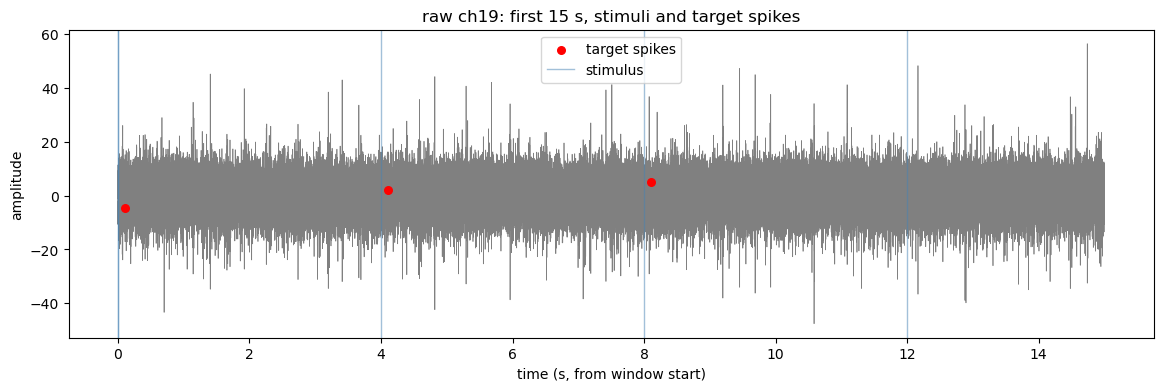

In [10]:
slice_seconds = 15                                    # how many seconds to show
n = int(slice_seconds * sample_frequency)             # that many samples
trace = ch19[:n]                                       # first 15 s of the windowed signal
time_axis = np.arange(n) / sample_frequency            # x-axis in seconds (0 to 15), relative to window_start

# stimuli and target spikes that fall inside this slice (times are absolute, so subtract window_start)
stim_in_slice   = ttls[(ttls >= window_start) & (ttls < window_start + slice_seconds)] - window_start
target_in_slice = ground_truth_in_window[(ground_truth_in_window >= window_start) &
                                          (ground_truth_in_window < window_start + slice_seconds)] - window_start

# amplitude at each target spike, so the dot sits on the trace
target_samples = np.round(target_in_slice * sample_frequency).astype(int)
target_amp = trace[target_samples]

plt.figure(figsize=(14, 4))
plt.plot(time_axis, trace, color="gray", lw=0.5)                      # the raw voltage trace
for t in stim_in_slice:
    plt.axvline(t, color="steelblue", alpha=0.5, lw=1)               # a line at each stimulus
plt.scatter(target_in_slice, target_amp, color="red", s=30, zorder=3, label="target spikes")
plt.axvline(stim_in_slice[0], color="steelblue", alpha=0.5, lw=1, label="stimulus")  # one labelled line for the legend
plt.xlabel("time (s, from window start)")
plt.ylabel("amplitude")
plt.title(f"raw ch19: first {slice_seconds} s, stimuli and target spikes")
plt.legend()
plt.show()

# 3. Detection by depth
This part is in three stages: 
First, detect spikes: find where the signal first dips below -k x noise, drop any dip that starts closer than 3 ms to the previous kept one and return the survivors as times in seconds.
**crossings:** contains everything that crossed the threshold.
**keep:** then it holds only the crossings from that list that are at least 90 samples after the last kept crossing (the refractory 3 ms) to remove duplicates.

Second, for each detection score, look for a nearby unclaimed true spike; if found, count a hit and claim that spike; then count the hits, false alarms, and misses and turn them into precision, recall and F1.
NOTE: The detector runs two rules:
1. threshold: signal drops below -1.5 x noise floor -> detect
2. Refractory: after a detection, ignore everything for ms to prevent counting the same spike more than once

Third, threshold sweep for detection
It tests the amplitude detector at five different threshold strengths and scores each one against the ground truth to see how detection quality changes as the threshold gets stricter. 

## Results: 
Detected spikes: ~76,000 at k=1.5 down to ~5,000 at k=4
Recall: 0.887 at k=1.5 to ~0.056 at k=4
Precision: stays flat near zero 
F1: 0.002 across all thresholds. 

## Opinion:
If false positives are noise, when the threshold is raised, it would have removed them and returned high precision. But precision stays near zero regardless of how strict the threshold is. This suggests that false positives are not noise but other fibres with similar amplitude to the target unit that cross the threshold at every k. 


In [11]:
# Helper functions for finding the spikes and scoring them against the ground truth in the window. 
def detect_spikes(data, sample_frequency, k=4, noise_std=None, refractory_ms=3.0):
    """
    Detect spikes by amplitude threshold on a negative-going signal.
    Flag every point where the signal drops below -k * noise, then enforces a refractory period so a single spike crossing the threshold more than once its counted as one

    Args:
        data (np.ndarray): 1D signal (one channel)
        sample_frequency (int): sampling rate in Hz (30000)
        k (float): threshold multiplier; lower catches more, higher is stricter. 
        noise_std (float or None): noise level; if None, estimated as MAD = median(|data|)/0.6745.
        refractory_ms (float): minimum gap between detections in ms.
    """
    if noise_std is None:
        noise_std = np.median(np.abs(data)) / 0.6745 # MAD: absolute value of every sample, take the median, divide by 0.6745
    threshold = -k * noise_std     # the cutoff a sample must go below to count
    below = data < threshold       # boolean mask, True where the signal is below the threshold
    crossings = np.where(np.diff(below.astype(int)) == 1)[0] + 1 # find the start of each dip, turn True/flase into 1/0; below the threshold is 1, above is 0. so, when 0 -> 1 = signal first drops below the line 
                                                                # np.diff() subtract each sample from the next, so a step from 0 up to 1 shows as +1 and 1 to 0 as -1. 
                                                                # == 1 keeps only the +1
                                                                # np.where()[0] returns the index position where that is true
                                                                # +1 shifts each index forward by one, because np.diff reports a change at the sample just before it happens
    min_gap = int(refractory_ms * sample_frequency / 1000)  # refractory period in samples (3ms -> 90)
    keep = []  # collect kept crossings
    last = -min_gap # index of the last kept crossing
    for crossing in crossings: 
        if crossing - last >= min_gap: # keep the crossings only if it's at least 90 samples after the last kept one, if kept 
            keep.append(crossing)      
            last = crossing        #if kept, record it and update
    return np.array(keep) / sample_frequency  # The kept values are divided by the sample frequency (30000), which turns them into seconds. 

def score_detections(detected, ground_truth_times, tolerance=0.002): 
    """
    Score detections against ground truth spike times
    Each detection is matched to a ground truth spike within tolerance.

    Args:
        detected (np.ndarray): detection times in seconds 
        ground_truth_times (np.ndarray): ground truth target spike times in seconds 
        tolerance (float): match window in seconds (e.g. 0.001 = +/- 1 ms)

    Returns:
            tuple(float, float, float): precision, recall, f1
                precision = tp/(tp+fp), recall = tp/(tp+fn), f1 = harmonic mean
    """
    matched_true = set() # A set that remembers which true spikes have already been claimed by a detection 
    tp = 0  # True-positive counter (hits) starts at 0
    for detection in detected: # Go through each detection
        close = np.where(np.abs(ground_truth_times - detection) <= tolerance)[0] # find true spiks near tis detection
        unmatched = [ground_truth_index for ground_truth_index in close if ground_truth_index not in matched_true] # Of those nearby true spikes, only keep the ones that are not already claimed by an earlier detection. 
        if len(unmatched) > 0: # if there's at least one unclaimed true spike nearby, this detection is a hit:
            tp += 1                        # count it as a true positive
            matched_true.add(unmatched[0]) # claim the first available true spike (mark it used,so no other detection can claim it) 
    fp = len(detected) - tp # false positives = detections that didn't hit anything (total detections - the hits)
    fn = len(ground_truth_times) - len(matched_true) # false negative = true spikes that got missed. Total true spikes - the ones that got claimed. 
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0 # precision = of everything detected, how many were real. 
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0 # Recall = of all the true spikes, how many were caught 
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0 # F1 = the harmonic mean of precision and recall. 
    return precision, recall, f1

In [12]:
# threshold detection sweep
# Run amplitude detector at five different thresholds and score each one
print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}") 
for k in [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]: # low k (0.5) = loose threshold catches lots of spikes. High k (4) is strict, so it only catches bigger dips. 
    #  detect at this threshold
    depth_detections = detect_spikes(ch19, sample_frequency, k=k) + window_start # run detector on the signal at this k, returs detetcions times relative to the window start
    precision, recall, f1 = score_detections(depth_detections, ground_truth_in_window, tolerance=0.002) # compare the detections to the ground truth spikes, with a +/- 2ms match window and return three mertics for this k.
    print(f"{k:5.1f} {len(depth_detections):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")
    if k == 1.5:
        number_detections_depth = len(depth_detections)
        precision_depth = precision
        recall_depth = recall
        f1_depth = f1

    k  detected  precision   recall      F1
  0.5    274924     0.0006    1.000   0.001
  1.0    261085     0.0007    0.983   0.001
  1.5    229677     0.0007    0.921   0.001
  2.0    170811     0.0007    0.701   0.001
  2.5    102178     0.0007    0.418   0.001
  3.0     53703     0.0007    0.209   0.001
  3.5     28548     0.0005    0.073   0.001
  4.0     16682     0.0005    0.051   0.001


# 4. Template Matching (Detection by shape)
### Threshold detection alone did not tell the target spike from other events, so this stage matches on shape instead of depth. 
This section, uses normalised cross-correlation trough aligned template (aligns each spike ot its trough) by building one average spike waveform (the template) from the 177 ground truth spikes. 
1. **Template_match** slides the template along the whole recording and, at every sample, measures how similar the signal there is to the template shape, and the output is a score at every sample running from -1 to +1, where high means the signal looks like a spike.
2. The score is a normalised correlation (Pearson), so it responds to shape, not amplitude, so a big spike and a small spike with the same shape both score high.
3. **find_peaks(scores, height=0.3, distance=90)**: finds the peaks in the score signal: local maxima at least 0.3 high and at least 90 samples (3ms refractory) apart, which converts the continuous score into a list of discrete detection positions. Producing 64,183 shape detections across the 900 s window. (Height 0.3 was chosen because when sweeping the shape threshold from 0.3 to 0.7, recall went from 0.77 to 0.042, while precision stayed around 0.001), so a stricter threshold discards target spikes without removing the false positives. 



In [13]:
#helper function for template matching

def template_match(signal, template):
    """
    Normalised cross-correlation between template and a signal
    Slides the zero-mean, unit-norm template along the signal and returns a match score at every sample. 

    Args:
        signal (np. ndarray): 1D signal to search
        template (np.ndarray): the average spike waveform to match. 

    Return:
        np.ndarray: match score in [-1, 1] at each sample.
    """
    template_centred = template - template.mean() #subtract the average so the template sits centred on zero, with equal weight above and below 
    template_unit = template_centred / np.linalg.norm(template_centred) # divide by its length (the square root of the sum of squared), so the template size 1 
                            # zero means removes the offset and unit norm removes the scale, together they turn a raw dot product into a proper correlation that lives in [-1. 1]
    template_length = len(template_unit) # template length in samples. 
    raw_match = correlate(signal, template_unit, mode='same') # At every position along the signal, slide the template, multiply and sum template against signal at every position, and give one value per sample. 
    
    # Measure the signal's size at every position, how big the signal is in each template width window. 
    local_mean   = uniform_filter1d(signal,    template_length, mode='nearest') # signal's local mean. Slide a window of width along the signal and average the values inside it.                                                   
    local_mean_sqr  = uniform_filter1d(signal**2, template_length, mode='nearest') #local mean of the signal squared
    local_variance = np.maximum(local_mean_sqr - local_mean**2, 0)  #local variance = (mean of squares) - (mean squared) and clipped at 0, so rounding cant make it negatie
    local_norm = np.sqrt(local_variance * template_length) 
    return np.divide(raw_match, local_norm, out=np.zeros_like(raw_match), where=local_norm > 1e-6) # Raw match / signal size = the final shape score [-1, 1]

def spike_latencies(spike_times, ttls):
    """
    Latency of each spike from the stimulus pulse
    For each spike, finds the most recent stimulus (TTL) before it and returns the time difference. 

    Args:
        spike_times (np.ndarray): spike times in seconds
        ttls (np.ndarray): stimulus pulse times in seconds

    returns :
        latency of each true spike in seconds
    """
    indx = np.searchsorted(ttls, spike_times) - 1
    ok = indx >= 0
    lat = spike_times[ok] - ttls[indx[ok]]
    return lat

# The latency constraint 
def in_latency_window(times, ttls, lat_min=0.085, lat_max=0.160):
    """
    for each detection, True if it fired at the right delay after a stimulus (between lat_min and lat_max), 
    false otherwise
    
    Args:
        times (np.ndarray): detection times in seconds 
        ttls (np.ndarray): stimulus pulse times in seconds
        lat_min (float): lower latency bound in seconds
        lat_max (float): upper latency bound in seconds

    return:
        np.ndarray: true where the detection's latency falls in the window
        The wide window (0.085-0.160); the tight bound is passed for a 5 ms window.  
    """
    indx = np.searchsorted(ttls, times) - 1
    has_ttl = indx >= 0
    latency = np.full(len(times), np.inf)
    latency[has_ttl] = times[has_ttl] - ttls[indx[has_ttl]]
    return (latency >= lat_min) & (latency <= lat_max)
    

In [14]:
# Build the template
half_width   = 45      # 1.5 ms template width on each side of the trough
align_window = 30      # 1 ms to find the real trough, because the marked spike times might be a bit off the true deepest point. 

spike_segments = [] # holds one clip per spike
for spike_time in ground_truth_in_window: # convert spike's time (seconds) to sample index in ch19: subtract the window start
    centre_index = int((spike_time - window_start) * sample_frequency) # then multiply by sample frequency to turn seconds into samples
    
    # cut a chunk wider than the final clip, leaving room to search for the trough
    lo, hi = centre_index - half_width - align_window, centre_index + half_width + align_window
    if lo < 0 or hi > len(ch19): # skip spikes that are too near the recording edge
        continue
    wide_window   = ch19[lo:hi]
    # look in align_window each side of the centre, find the deepest sample (the trough)
    centre = half_width + align_window # middle of the wide_window where the marked spike sits
    trough_index = np.argmin(wide_window[centre - align_window : centre + align_window]) + (centre - align_window)
    
    # Cut 45 samples each side of the trough, a 90 sample clip centred on the deepest point. 
    spike_segment = wide_window[trough_index - half_width : trough_index + half_width]
    if len(spike_segment) == 2 * half_width:
        spike_segments.append(spike_segment)

spike_segments = np.array(spike_segments) # Stack all the clips into an array, then average down the columns. 
template = spike_segments.mean(axis=0) # the average is the template. 

print("spikes averaged:", len(spike_segments))  
print("template trough: %.2f" % template.min())
print("trough / noise:  %.2f" % (abs(template.min()) / noise_mad)) # how deep is the spike compared to the noise. 

spikes averaged: 177
template trough: -11.04
trough / noise:  2.23


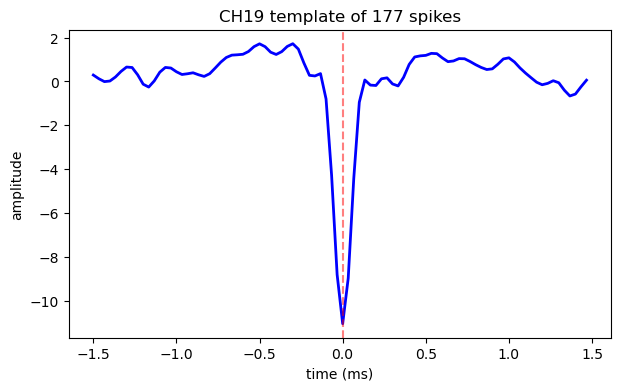

In [15]:
# plot the template 
time_ms = (np.arange(2 * half_width) - half_width) / sample_frequency * 1000
plt.figure(figsize=(7, 4))
plt.plot(time_ms, template, 'b', linewidth=2)
plt.axvline(0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('time (ms)'); plt.ylabel('amplitude')
plt.title('CH19 template of %d spikes' % len(spike_segments))
plt.show()

In [16]:
# Runthe over the whle signal and check the score range
scores = template_match(ch19, template)
print("score range: %.3f to %.3f" % (scores.min(), scores.max()))
print("zeroed samples:", (scores == 0).sum())

score range: -0.950 to 0.884
zeroed samples: 608


In [17]:
# Similarity threshold sweep 
# height=th is the shape similarity threshold: find_peaks keeps only peaks scoring at least th (-1 to +1). 
# Higher th = stricter match, so only spikes very similar to the template are kept
# Lower th = looser match, more peaks (more false positives). 

print(f"{'thresh':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]: # try five different similarity thresholds 
    peaks, _ = find_peaks(scores, height=th, distance=90) # find peaks in the match score signal. Only keep peaks scoring at least 'th' (threshold)  
    shape_detections = peaks / sample_frequency + window_start # Convert peak sample positions to absolute time in second
    precision, recall, f1 = score_detections(shape_detections, ground_truth_in_window, tolerance=0.002) # score this threshold's detections against the 71 true spikes, +/-2 ms match tolerence 
    print(f"{th:7.1f} {len(peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

 thresh  detected  precision   recall      F1
    0.3    193458     0.0007    0.814   0.001
    0.4    149377     0.0008    0.644   0.002
    0.5     76525     0.0008    0.333   0.002
    0.6     25838     0.0007    0.096   0.001
    0.7      5536     0.0011    0.034   0.002


## 5. Latency constraint
Template matching (shape) kept the target spikes but also detected other events, so precision is low, as seen in the similarity scores above. The target fibres fire at a consistent delay after each stimulus, which other fibres do not share, so this latency constraint stage filters detections by timing to remove them. So the contrast and shape could not separate target spikes from other events, but timing can; this is the point of this section. 
### Three steps to do this:
1. **Measure each detection's latency**: for every detection, find the stimulus pulse just before it and measure the delay between them. That delay is the latency. 
2. **Only keep detections in the latency band**: so a detection is kept only if its latency falls within a window around the target's typical delay.
3. **Why that width**: An 8 ms width was chosen

### Results:

In [18]:
# Find the best latency window: centre on the median ground truth latency, and sweep the half_width
#in_latency_window expects seconds; lo/hi are converted to seconds (/1000) on their line
# both ground_truth_latency and median_latency are in ms

ground_truth_latency = spike_latencies(ground_truth_in_window, ttls) * 1000 # take the 177 target spikes and compute each one's latency and convert them from s to ms
median_latency = np.median(ground_truth_latency) 
peaks, _ = find_peaks(scores, height=0.3, distance=90) # scan the match score signal and return the sample positions of every shape match,
                                                    # that is both at least 0.3 strong and 90 samples (3ms) apart from the next 
print("shape detections (before latency:", len(peaks))
shape_detections = peaks / sample_frequency + window_start #convert those peak positions from sample indices into absolute times in seconds. 

print(f"{'window (ms)':>16s} {'width':>6s} {'kept':>6s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for latency_half_width in [0.5, 1.0, 1.5, 2, 2.5, 3, 3.5, 4, 5, 6, 7]: # try each half_width in turn in ms. How far each side of the median is accepted
    lo, hi = (median_latency - latency_half_width)/1000, (median_latency + latency_half_width)/1000 #lo = median minus the half_width, hi = median plus the half_width
                                                                                                    # both are converted from ms to seconds. 
    
    latency_detections = shape_detections[in_latency_window(shape_detections, ttls, lat_min=lo, lat_max=hi)] # only keep the shape detection where post stimulus latency falls in [lo, hi] 
    precision, recall, f1 = score_detections(latency_detections, ground_truth_in_window, tolerance=0.002) # score detections against the 71 ground truth spikes , +/- 2ms tolerance.
    print(f"  {median_latency-latency_half_width:.1f}-{median_latency+latency_half_width:.1f} {2*latency_half_width:6.0f} {len(latency_detections):6d} {precision:10.3f} {recall:8.3f} {f1:7.3f}")

shape detections (before latency: 193458
     window (ms)  width   kept  precision   recall      F1
  99.6-100.6      1     45      0.489    0.124   0.198
  99.1-101.1      2     87      0.437    0.215   0.288
  98.6-101.6      3    116      0.388    0.254   0.307
  98.1-102.1      4    161      0.373    0.339   0.355
  97.6-102.6      5    203      0.355    0.407   0.379
  97.1-103.1      6    245      0.359    0.497   0.417
  96.6-103.6      7    292      0.339    0.559   0.422
  96.1-104.1      8    329      0.334    0.621   0.435
  95.1-105.1     10    400      0.300    0.678   0.416
  94.1-106.1     12    490      0.276    0.763   0.405
  93.1-107.1     14    566      0.253    0.808   0.385


In [19]:
# Tight latency constraint
# Apply the chosen 8ms window (96.1-104.1)
tight_lo = (median_latency - 4) / 1000 # take the median latency, subtract 4 (half_width) to get the lower bound (97.6 ms), then convert ms to seconds
tight_hi = (median_latency + 4) / 1000 # same thing just median pluse 4
# Apply the constraint
tight_detections = shape_detections[in_latency_window(shape_detections, ttls, lat_min=tight_lo, lat_max=tight_hi)]
precision, recall, f1 = score_detections(tight_detections, ground_truth_in_window, tolerance=0.002) # score detection against thr 71 spikes 

tp = round(recall * len(ground_truth_in_window)) #target spikes caught
fp = len(tight_detections) - tp  # detections kepat that are not target spikes
fn = len(ground_truth_in_window) - tp # target spikes missed

print("tight latency window: %.1f-%.1f ms" % (median_latency - 4, median_latency + 4))
print("kept: %d   TP: %d   FP: %d   FN: %d" % (len(tight_detections), tp, fp, fn))
print("precision: %.3f   recall: %.3f   F1: %.3f" % (precision, recall, f1))

tight latency window: 96.1-104.1 ms
kept: 329   TP: 110   FP: 219   FN: 67
precision: 0.334   recall: 0.621   F1: 0.435


In [20]:
print("type:", type(scores))
print("shape:", scores.shape)
print("dtype:", scores.dtype)
print("first 5:", scores[:5])
print("min, max:", scores.min(), scores.max())

type: <class 'numpy.ndarray'>
shape: (27000000,)
dtype: float64
first 5: [-0.22462844 -0.23840451 -0.18554775 -0.07150159  0.05230744]
min, max: -0.949755091391741 0.8843374292099632


In [21]:
# Validation check
# check 1: does the time-to-index conversion land on a real spike
spike_time = ground_truth_in_window[0]   # first true spike time
centre_index = int((spike_time - window_start) * sample_frequency) # where does the spike sit within the score array
print("first spike_time :", spike_time)
print("centre_index     :", centre_index, " (a whole number, 0 to 9,000,000)") # the spike sits at what position
print("score at that idx:", scores[centre_index]) # what is the match score at that position? low = weak match, high = high match
print("max near it:", scores[centre_index-90:centre_index+90].max()) # what about at a small window around the position, is there a match? 


first spike_time : 3602.7732333333333
centre_index     : 3073  (a whole number, 0 to 9,000,000)
score at that idx: 0.06908561875168709
max near it: 0.44832209957782465


In [22]:
#validation check
# Check 2: Do the inputs have the right type, length and units
print("ground_truth_in_window") 
print("type:", type(ground_truth_in_window))
print("len:", len(ground_truth_in_window))
print("first 5:", ground_truth_in_window[:5])
print("window_start")
print(" value:", window_start)
print("sample_frequency")
print("  value:", sample_frequency)
print("scores")
print("len:", len(scores))
print("range:", scores.min(), "to", scores.max())

ground_truth_in_window
type: <class 'numpy.ndarray'>
len: 177
first 5: [3602.77323333 3606.7741     3610.7746     3618.77576667 3622.7765    ]
window_start
 value: 3602.6708
sample_frequency
  value: 30000
scores
len: 27000000
range: -0.949755091391741 to 0.8843374292099632


# 5. Overlapping 
**Consumes:** peaks, scores, ground_truth_in_window, peak_times, sample_frequency, window_start
**Does:**
1. tests how wide the search window must be to catch each spike's peak
2. measures the score at each true spike vs at all other detections and compares distributions
3. Computes d-prime between target and non-target detections
4. 
**produces**:
1. The width test produces the chosen search window +/-90
2. The overlap diagnostic produces two distributions: true spike median 0.519 and all peaks median 0.475
3. The d-prime : is_target (64183 bool), target_scores (~57), nontarget_scores(~64126), d_prime(0.296)

### NOTE:
***Aksenova et al., 2003: Overlapping spikes are a recognised limitation that degrades sorting performance, and their method did not address it.*** 
### What does d-prime do and how 
Normally, d-prime measures how well spike sorting separates one unit's cluster from others, computed on waveform principal components using LDA. Higher values mean the unit is better isolated. 

Here, because only one template and one match score axis is available, the same separation formula was applied to the 1D match score, comparing target detections (near a true spike) and non-targets (everywhere else). If shape matching (template matching) worked, targets should score high and non-targets low. If it fails, the two will score similar numbers. It gives a single number of how separable are targets from non targets on the shape score. 
Formula: d_prime = (target_scores.mean() - nontarget_scores.mean()) / np.sqrt(0.5*(target_scores.var() + nontarget_scores.var()))

In [23]:
# How wide does the search window need to be to catch each spike's peak? 
# Measure the highest match score near each true spike at four different window widths
for search_half in [90, 60, 45, 30]:
    spike_scores = []
    for spike_time in ground_truth_in_window:
        centre_index = int((spike_time - window_start) * sample_frequency)
        if search_half < centre_index < len(scores) - search_half:
            spike_scores.append(scores[centre_index-search_half:centre_index+search_half].max())
    spike_scores = np.array(spike_scores)
    print("search_half=%3d (%.1f ms each side): median %.3f, min %.3f" % (search_half, search_half/30, np.median(spike_scores), spike_scores.min()))

search_half= 90 (3.0 ms each side): median 0.504, min 0.325
search_half= 60 (2.0 ms each side): median 0.464, min 0.268
search_half= 45 (1.5 ms each side): median 0.437, min 0.268
search_half= 30 (1.0 ms each side): median 0.413, min 0.209


In [24]:
# Measure the template match score at every 71 spikes and at all detected peaks, then compare the two distributions 
# a search window of +/- 90 sample (3 ms)
ground_truth_scores = [] # empty list for one match score per spike
for spike_time in ground_truth_in_window: # loop through the 71 spike times, one at a time
    centre_index = int((spike_time - window_start) * sample_frequency) # Convert that spike's time into its position in the scores array
    if 90 < centre_index < len(scores) - 90: # only processed if the spike is at least 90 samples from either edge of the array
        ground_truth_scores.append(scores[centre_index-90:centre_index+90].max()) # look in a window 90 samples each side of the spike (a 180 sample = 6 ms window), take the highest score in it, and add that to the list. 
                                                                                #max()) because the exact peak of the match migh sit a sample or two off the ground-truth mark, so the best score nearby is taking rather than the score at the exact index. this is to record how well did the template match at this true spike. 

ground_truth_scores = np.array(ground_truth_scores) # turn the finished list into a numpy array to run median and percentiles on it
peaks, _ = find_peaks(scores, height=0.3, distance=90) # find all the detection peaks in the whole score signal (
print("true spikes: median score: %.3f, 5th: %.3f, 95th: %.3f" % (np.median(ground_truth_scores), np.percentile(ground_truth_scores,5), np.percentile(ground_truth_scores,95)))
print("all peaks: median score: %.3f, 5th: %.3f, 95th: %.3f" % (np.median(scores[peaks]), np.percentile(scores[peaks],5), np.percentile(scores[peaks],95)))

true spikes: median score: 0.504, 5th: 0.379, 95th: 0.669
all peaks: median score: 0.472, 5th: 0.332, 95th: 0.669


In [25]:
# d-prime between target-matched and non-target detections 
# peak_times is the detection of every peak, in seconds, to be compared against the ground-truth spike times
peak_times = peaks / sample_frequency + window_start # convert peak from a sample position to an absolute time in seconds. 
                                                    # peaks are positions in the scores array; dividing by sample_frequency (30000) turn poistion into seconds
                                                    # adding window_start shifts to recording time. 
tolerance = 0.002 # A peak counts as a target if it lands within 2 ms of a true spike. 


diffs = np.abs(peak_times[:, None] - ground_truth_in_window[None, :]) # build a table of distance for how far every peak from every true spike
is_target = (diffs <= tolerance).any(axis=1) # make the table: a signal True/False per peak (is this peak close to any spike.
#Make two groups for peak scores.
target_scores = scores[peaks][is_target] # scores of peaks that are the target spikes' peaks
nontarget_scores = scores[peaks][~is_target] # scores of peaks that are other peaks

print("target peaks:", len(target_scores), " non-target peaks:", len(nontarget_scores)) # confirm the two groups are seprate 

# pritn the gap between the group means and the pooled spread
print("numerator (mean gap):", target_scores.mean() - nontarget_scores.mean()) 
print("denominator (pooled sd):", np.sqrt(0.5*(target_scores.var() + nontarget_scores.var())))

# mean gap divided by pooled spread. distance of mean over sqrt of average variance
d_prime = (target_scores.mean() - nontarget_scores.mean()) / np.sqrt(0.5*(target_scores.var() + nontarget_scores.var()))
print("d-prime (target vs non-target): %.3f" % d_prime)

target peaks: 152  non-target peaks: 193306
numerator (mean gap): -0.005136992212473379
denominator (pooled sd): 0.10001078033577497
d-prime (target vs non-target): -0.051


In [26]:
def whats_inside(name, x):
    if np.isscalar(x):
        print(f"{name}: single value = {x}")
    else:
        print(f"{name}: {type(x).__name__}, length {len(x)}, first few {x[:3]}")

whats_inside("peaks", peaks)
whats_inside("peak_times", peak_times)
whats_inside("scores", scores)
whats_inside("is_target", is_target)
whats_inside("ground_truth_in_window", ground_truth_in_window)

peaks: ndarray, length 193458, first few [ 82 255 352]
peak_times: ndarray, length 193458, first few [3602.67353333 3602.6793     3602.68253333]
scores: ndarray, length 27000000, first few [-0.22462844 -0.23840451 -0.18554775]
is_target: ndarray, length 193458, first few [False False False]
ground_truth_in_window: ndarray, length 177, first few [3602.77323333 3606.7741     3610.7746    ]


# 6. One-Class SVM

In [27]:
# Helper function
# Trough aligned extraction: finds the trough and cuts the 90 sample waveform 
# Here every spike is centred the same way regardless of how it was marked
# this version is the one used for SVM because it fixes the misalignment 
half_width_svm = 45   # 45 samples each side = 90-sample waveform
def extract_aligned_waveform(spike_time, signal=None):
    """
    Cut a 90 sample waveform centred on the spike's trough (deepest point)
    Extract a wider window first (wider research window, 70 half width instead of 45), find the trough, then take 45 samples either side ot it. 
    return None if a spike is too close to the edge for the wide window 
    Args:
        spike_time (float): time of the spike in seconds
    return:
        no.ndarray of 90 voltage samples centred on the trough or None
    """
    if signal is None:
        signal = ch19
    position = int(round((spike_time - window_start) * sample_frequency)) # convert a spike's time to position
    wide_half_width = 70 # wider half window so there's room to re-centre on the trough 
                        # a wider half window (70 instead of 45) to find the trough and then recenter on it
    
    # only extract 140 samples fit (half width of 70)
    if position - wide_half_width < 0 or position + wide_half_width > len(signal):
        return None #skip any waveform where spikes are too close to the edge for a 140 sample waveform
    
    wide_waveform = signal[position - wide_half_width : position + wide_half_width] # winder waveform for the 140 sample search 
    trough_offset = np.argmin(wide_waveform)  # deepest point in the full wide clip  
    trough_position = position - wide_half_width + trough_offset  # convert the offset to a position in the full ch19. 
    
    # second garud for the final window  (around the trough)
    if trough_position - half_width_svm < 0 or trough_position + half_width_svm > len(signal): 
        return None
    return signal[trough_position - half_width_svm : trough_position + half_width_svm] # cut the final 90 samples (45 from either side) that are centred on the trough


In [28]:
#Confirm the extraction works: extract one spike and verify it's centred on the trough.
test = extract_aligned_waveform(ground_truth_in_window[0]) #aligned extraction on one the first ground truth spike 
print("length:", len(test))# length of retruned waveform (should be 90)
print("trough at sample:", np.argmin(test)) # where the deepest sample sists with in the retruned waveform (should be 45 centred 

length: 90
trough at sample: 45


In [29]:
# Build the target class (positive class) for the SVM: the 177 ground truth spikes, 
# each extracted as a trough-aligned 90-sample waveform
training_aligned = [] 
for spike_time in ground_truth_in_window: #loop through the 1 target spike time
    waveform = extract_aligned_waveform(spike_time) # extract this spike's trough aligned waveform 
    if waveform is not None: # only keep if extraction succeeded, so skip any spike too close to the signal edge
        training_aligned.append(waveform)
        
training_aligned = np.array(training_aligned) # stack into an array: rows = spikes, columns = 90 samples

print("trainng aligned shape:", training_aligned.shape) 
print("training trough at:", np.argmin(training_aligned.mean(axis=0))) # where the average spike's trough is centred (should be 45)
print("training range:", training_aligned.mean(axis=0).min(), "to", training_aligned.mean(axis=0).max()) # the average spike's depth (min) and peak (max)

trainng aligned shape: (177, 90)
training trough at: 45
training range: -13.254279433691552 to 2.100862367892237


In [30]:
survivor_is_target = np.array([np.any(np.abs(ground_truth_in_window - d) <= 0.002)
    for d in tight_detections
])

# 7. Denoisers

In [31]:
# Helper function for denoisers
# Wavelet denoising: real spikes become a few large coefficients, noise becomes many small ones.
# Decompose into scales, zero the small noise coefficients, rebuild

def denoise_swt_channel(channel, wavelet='db4', level=4):
    """
    Satationary wavelet transform denoising of one channel
    Decomposes with SWT, soft-thresholds the detail coefficients using a level dependent universal threshold, reconstruct with inverse SWT. 
    Args: 
        channel (np.ndarray): one channel of the signal (1D, voltage sample)
        wavelet (str): wavelet family for decomposition (default 'db4')
        level (int): number of WT decomposition level (default is 4)
    return:
        np.ndarray: the denoised channel, same length as the input
    """
    signal_length = len(channel)
    pad = (-signal_length) % (2 ** level) 
    if pad:
        channel = np.pad(channel, (0, pad), mode='reflect')

    # decompose: list of (cA, cD) pairs, one per level
    coeffs = pywt.swt(channel, wavelet, level=level) # step 1: decompose into scales )approximation + detail per level) 

    # threshold each level's detail coefficients
    denoised_coeffs = []
    for cA, cD in coeffs: # cA = coefficients Approximation (keep), cD = coefficient details (has the noise)
        
        sigma = np.median(np.abs(cD)) / 0.6745 # noise estimate for this level
        threshold = sigma * np.sqrt(2 * np.log(len(cD))) # coefficients below this are noise
        cD_thresh = pywt.threshold(cD, threshold, mode='soft') # Step 2: zero the small (noise) coefficients
        denoised_coeffs.append((cA, cD_thresh)) # keep the approximation untouched

    denoised = pywt.iswt(denoised_coeffs, wavelet) # Step 3: inverse swt, rebuild the signal, now that the noise removed
    return denoised[:signal_length] # trim padding

# Dense Autoencoder training pair
# Make 40000 training examples, each a window 60 samples clip 
#jitter=8 = max random shift of the spike
# spike_fraction=0.5 is half the window contains a spike, and half are noise
def make_training_pairs_real(n=40000, window=60, jitter=8, spike_fraction=0.5, seed=0):
    """
    Generate training pairs for the denoisers using the real spike template.
    Resample the real average spike to the window length. Each window either contains one spike (the template randomly shifted and scaled 
    or, is only noise. gaussin noise is then add to make the noisy input; the clean version is the ground truth target

    Args:
        n (int) number of windows
        window (int): samples per window
        jitter (int): max random shift of the spike in samples
        spike_fraction (float): fraction of windows that contains a spike
        seed(int): random seed for reproducibility
    retun:
        tuple(torch.Tensor, torch.Tencosr: (noisy, clean), each shape (n, window)
    """
    random_gen = np.random.default_rng(seed) # creat a random number generator with a fixed seed, so the same random choices happen evey run
    spike_shape = template.copy() # copy average spike shape
    # resample the template from its original length 90 to window length 60. 
    original_position = np.linspace(0, 1, len(spike_shape)) #original sample position
    new_position = np.linspace(0, 1, window)
    spike_shape = np.interp(new_position, original_position, spike_shape)

    spike_shape = spike_shape / np.abs(spike_shape.min()) # normalise the template so its trough (deepest point) is -1. 
    clean = np.zeros((n, window)) # create the clean target array: n raws (examples, each window long, all zeros to start. 
                                # raws that get a spike will be filled; rows left as zeros are noise only examples.
    for i in range(n):
        if random_gen.random() < spike_fraction: # loop over all 'n'S. random_gen gives a number 0-1; if its below spike_fraction (0.5), so this example gets a spike (so ~50 do). the rest stay zeros (noise only
         
            
            spike_shift = random_gen.integers (-jitter, jitter + 1) # spike_shift = a random shift between -8 and +8 samples, so the spike is not always on centre, so it teaches the AE spikes can be slightly off position
            spike_amplitude = random_gen.uniform(0.5, 3.0) # spike_amplitude is a random amplitide 0.5-3.0 so the AE sees spikes of different sizes
            clean[i] = np.roll(spike_shape, spike_shift) * spike_amplitude
    
    # Add noise to make noisy inputs
    noise_std = random_gen.uniform(0.1, 0.6, size=(n, 1)) # random level of noise level per example, so each window gets its own noise strength so the AE gets trained with varying noise
    noisy = clean + random_gen.normal(0, 1, size=clean.shape) * noise_std # 
            
    return (torch.tensor(noisy, dtype=torch.float32), torch.tensor(clean, dtype=torch.float32)) #return noisy, clean as PyTorch tensors, the noisy inputs and clean target for trainnig


#Apply the autoencoder across the whole signal
# the ae trained on a short 60 windows first, then to denoise a long signal, slide the window across it, denoise each window.
# Overlap: the window is 60 wide but slides by only 20 steps, so windows overlap, so each sample ends up covered by ~3 windows, giving ~ denoised estimate
# This estimate gets summed (denoised output and count how many covered each sample (overlap_count), then divide to average them.

def ae_denoise_signal(channel, denoiser, window=60, step=20):
    """
    Apply a trained autoencoder across a long signal with overlapping windows.
    Slides a window, normalises each by MAD scale, then runs the model, unnormalises, and averages the overlaps
    Args:
        channel (np.ndarray): the channel (signal) to denoise
        denoiser (nn.Module): a trained autoencoder
        window (int): window length in samples
        step (int): straide between windows(overlp = window - step)
    returns:
        np.ndarray: the denoised signal, same length as input
    """
    denoiser.eval() # put the model in evaluation mode
    denoised_output = np.zeros(len(channel)) # an array of zeros, where denoised values get added up
    overlap_count = np.zeros(len(channel)) #how many windows cover each sample 
    
    noise_scale = np.median(np.abs(channel)) / 0.6745 # MAD noise level used to normalise each window before feeding the model, because the model was trained on normalised data, so imputs should be scaled the same way. 
    
    with torch.no_grad(): # So PyTorch deosnt track gradients as it is not neccessary for running the model
        # slide the window across 
        for start in range(0, len(channel) - window, step): #start where each window starts, going by 20
            segment = channel[start:start+window] # Current window 
            
            # skip near zero standard deviation 
            if segment.std() < 1e-6: # window spread, if tiny skip because nothing to denoise 
                continue 

            segment_normalised = segment / noise_scale # the normalised window (divided by the noise scale)
            # run the normalised window through the model, get the denoised output and convert back to numpy
            reconstruction = denoiser(torch.tensor(segment_normalised, dtype=torch.float32)).numpy()
            denoised_output[start:start+window] += reconstruction * noise_scale # after denoising this window, add it back at the same possition
            overlap_count[start:start+window] += 1 

            
    overlap_count[overlap_count == 0] = 1 #avoid dividing by zeros at uncovered edges
    return denoised_output / overlap_count # average: sum / number of windows that covered each sample

def conv_ae_denoise(channel, denoiser, window=60, step=20):
    """
    Apply a trained Conv autoencoder across a long signal with overlapping windows. 
    Same sliding and averging as dense autoencoder above, but reshape each window tp (1, 1, window) for conv layers.
    Args:
        channel(np.ndarray): the signal to denoise
        denoiser (nn.Modul): a trained conv autoencoder
        window (int): window length in sample
        step(int): stride between window
    returns:
        np.ndarray: the denoised signal, same length as input
    """
    denoiser.eval()
    denoised_output = np.zeros(len(channel))
    overlap_count = np.zeros(len(channel))
    noise_scale = np.median(np.abs(channel)) / 0.6745
    with torch.no_grad():
        for start in range(0, len(channel) - window, step):
            segment = channel[start:start+window]
            if segment.std() < 1e-6:
                continue
            # normalise the window and reshape tp (1, 1, 60): conv layes need (batch, channel and length
            model_input = torch. tensor (segment / noise_scale, dtype=torch.float32).view(1, 1, window) # reshape to 1, 1, 60) 
            reconstruction = denoiser(model_input).view(-1).numpy() # run the window through the model, then flatten the 1, 1, 60 output back to a 60 sample array 
            denoised_output[start:start+window] += reconstruction * noise_scale
            overlap_count[start:start+window] += 1
        overlap_count[overlap_count == 0] = 1
        return denoised_output / overlap_count

In [32]:
# Run wavelet denoiser on the first 1000,000 samples of ch19
test = denoise_swt_channel(ch19[:100000]) 
print("input length:", len(ch19[:100000]))#length of the input slice
print("output length:", len(test)) # #length of the denoiseed output
print("input MAD:", np.median(np.abs(ch19[:100000])) / 0.6745)  # compute the noise level of the input slcie using MAD
print("output MAD:", np.median(np.abs(test)) / 0.6745) # compute the noise level of the denoised ouput. 

input length: 100000
output length: 100000
input MAD: 4.921186994538063
output MAD: 2.22692747089203


In [33]:
class DenseDAE(nn.Module):
    """
    Dense denoising autoencoder for one window of signal. Compresses a 60 sample window down to a 15 unit (ecoder),
    then reconstructs it back to 60 samples (decoder. The encoder forces the network to keep only important structure (the spike shape) 
    and drop the noise, so training on noisy -> clean pairs teaches it to denoise.
    Encoder 60 -> 30-? 15, decoder 15 -> 30 -> 60
    Args:
        window (int): input/output length in sample (default 60)
        hidden (int): latent dimension, the compresed middle (default 15)
    """
    def __init__(self, window=60, hidden=15):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(window, 30), nn.ReLU(),      # 60 -> 30
            nn.Linear(30, hidden), nn.ReLU(),      # 30 -> 15
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden, 30), nn.ReLU(),      # 15 -> 30
            nn.Linear(30, window),                 # 30 -> 60
        )
    def forward(self, x): 
        return self.decoder(self.encoder(x))

class ConvDAE(nn.Module):
    """
    Convolutional denoising autoencoder for one window of signal. Similar to dense, it compresses a 60 sample window to a decoder
    and reconstructs it, but uses 1D convloutions instead of linear layers.
    A connvolution slides a small filter (kernel=3) across the window, detecting local spike shaped patterns wherever they occur, so it haduls spikes at different positions better than dense version.
    Endoder length 60 -> 30-> 15 and decoder reverse it back to 60 samples. 
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=1, padding=1), nn.ReLU(), #60
            nn.Conv1d(16, 32, 3, stride=2, padding=1), nn.ReLU(), #30
            nn.Conv1d(32, 64, 3, stride=2, padding=1), nn.ReLU(), #15
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(), #30
            nn.ConvTranspose1d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(), #60
            nn.Conv1d(16, 1, 3, stride=1, padding=1), # linear output
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
        

In [34]:
# Create training data: noisy/clean window pairs from the real template
noisy_windows, clean_windows = make_training_pairs_real(n=40000, window=60, jitter=8, spike_fraction=0.5, seed=0)
print("noisy_windows:", noisy_windows.shape)   
print("clean_windows:", clean_windows.shape)   

noisy_windows: torch.Size([40000, 60])
clean_windows: torch.Size([40000, 60])


In [35]:
# Train dense AE
torch.manual_seed(0) # reproducible weiths 

dense_denoiser = DenseDAE(window=60, hidden=15) # create the model with 60 sample input; and set the compressed middle to 15 units 
optimiser = torch.optim.Adam(dense_denoiser.parameters(), lr=1e-3) # create an optimiser that updates the model's weight so it learns
mse_loss = nn.MSELoss() #MSE (mean squared error) measure how far the model's output is from the clean target, squares the differences, averages them (traiing minimises this average)
training_data = torch.utils.data.TensorDataset(noisy_windows, clean_windows) #Pair each noisy window with its matching clean window
batches = torch.utils.data.DataLoader(training_data, batch_size=256, shuffle=True) # split the 40000 window into groups of 256 per natch 

for epoch in range(30): # Repeat the whole training process 30 times, so one epoch = one epoch full pass through all 40000windows
    epoch_loss = 0 # 
    #loop over the batches, each pass gives 256 noisy windows and their 256 clean targets
    for noisy_batch, clean_batch in batches:
        optimiser.zero_grad() # clear the previous batch's gradient before each update
        loss = mse_loss(dense_denoiser(noisy_batch), clean_batch) # run noisy window through the model to get its denoised output
                                                                #measure how far that output is from the clean target
                                                                    # loss measures how wrong the model was on this batch 
        loss.backward() # compute for every weight, which direction would reduce the loss
        optimiser.step() # update the weights and nudge each in the direction that lowers the loss
        epoch_loss += loss.item() #  add the batch's loss to the epoch's running total
   # print the progeress at epochs 0, 10, 20, and 29 and show each's number and average loss to 4 decimals
    if epoch %10 == 0 or epoch == 29: 
        print(f"epoch {epoch:2d} loss {epoch_loss/len(batches):.4f}")

epoch  0 loss 0.0440
epoch 10 loss 0.0041
epoch 20 loss 0.0036
epoch 29 loss 0.0034


In [36]:
#test dense model
test_dense = ae_denoise_signal(ch19[:100000], dense_denoiser)
print("slice length:", len(test_dense))
print("input MAD:", np.median(np.abs(ch19[:100000])) / 0.6745)
print("dense AE MAD:", np.median(np.abs(test_dense)) / 0.6745)

slice length: 100000
input MAD: 4.921186994538063
dense AE MAD: 0.5662485075580522


In [37]:
#Train Conv AE
torch.manual_seed(0) # reproducible weight

conv_denoiser = ConvDAE() # creat the conv untrained model
noisy_conv = noisy_windows.unsqueeze(1) #(40000 windows, 60 samples) -> (40000, 1, 60) 1 = single channel,  because Conv layers needs channel dimensions. 
clean_conv = clean_windows.unsqueeze(1) 
optimiser = torch.optim.Adam(conv_denoiser.parameters(), lr=1e-3) 
mse_loss = nn.MSELoss() 

batches = torch.utils.data.DataLoader( 
    torch.utils.data.TensorDataset(noisy_conv, clean_conv), batch_size=256, shuffle=True) 

for epoch in range(30): # repeat the whole tarining process 30 times 
    epoch_loss = 0
    for noisy_batch, clean_batch in batches:
        optimiser.zero_grad()
        loss = mse_loss(conv_denoiser(noisy_batch), clean_batch)
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item()
    # print the progeress at epochs 0, 10, 20, and 29 and show each's number and average loss to 4 decimals
    if epoch % 10 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}  loss {epoch_loss/len(batches):.4f}")

epoch  0  loss 0.0216
epoch 10  loss 0.0077
epoch 20  loss 0.0075
epoch 29  loss 0.0074


In [38]:
#test conv model
test_conv = conv_ae_denoise(ch19[:100000], conv_denoiser)
print("slice length:", len(test_conv))
print("input MAD:", np.median(np.abs(ch19[:100000])) / 0.6745)
print("conv AE MAD:", np.median(np.abs(test_conv)) / 0.6745)

slice length: 100000
input MAD: 4.921186994538063
conv AE MAD: 0.958583775141123


In [40]:
# Denise the full window
ch19_wavelet = denoise_swt_channel(ch19)
ch19_dense   = ae_denoise_signal(ch19, dense_denoiser)
ch19_conv    = conv_ae_denoise(ch19, conv_denoiser)

In [41]:
print("raw:", np.median(np.abs(ch19))/0.6745)
print("wavelet: ", np.median(np.abs(ch19_wavelet))/0.6745)
print("dense:   ", np.median(np.abs(ch19_dense))/0.6745)
print("conv:    ", np.median(np.abs(ch19_conv))/0.6745)

raw: 4.958328650429573
wavelet:  2.2529623026624392
dense:    0.5592092327436688
conv:     0.9680910867996584


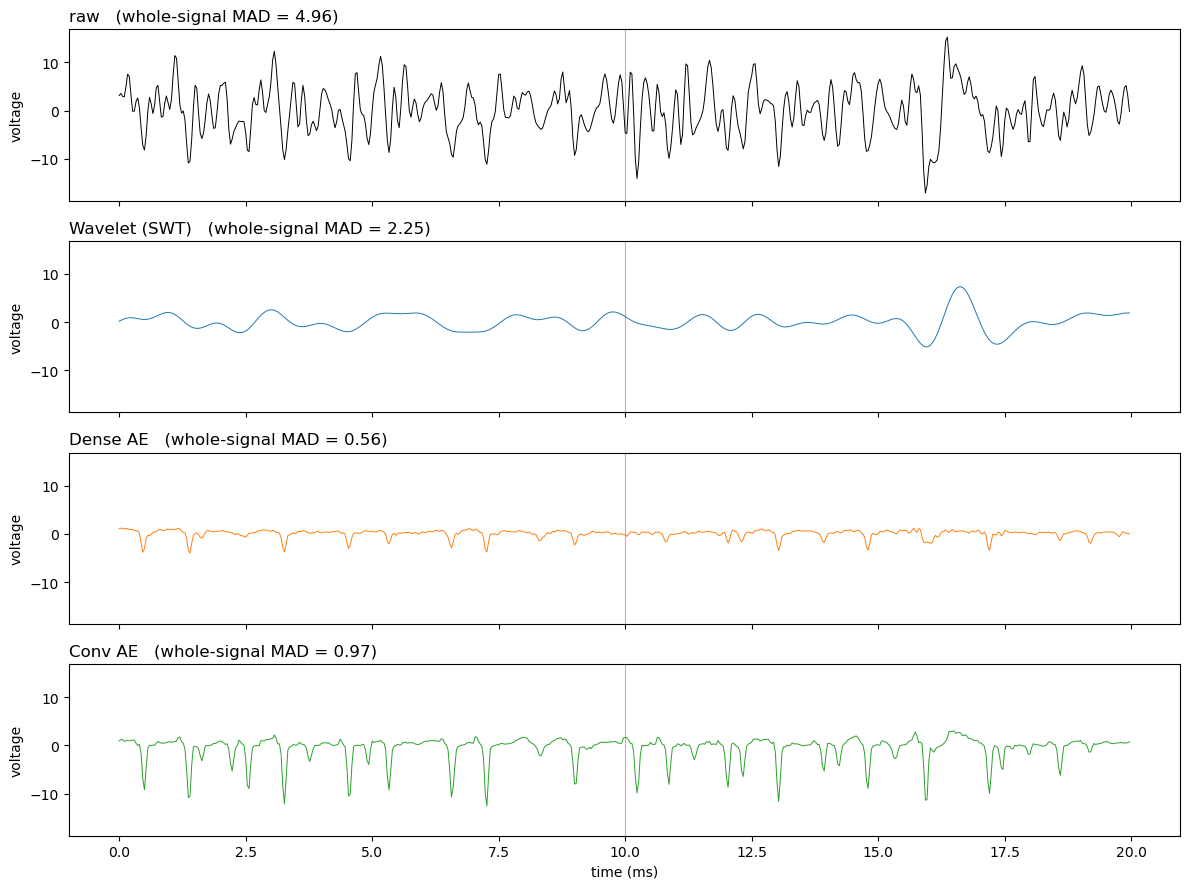

In [42]:
def mad(signal):
    return np.median(np.abs(signal)) / 0.6745

# whole-signal MADs (representative, computed over all 900 s)
mad_raw = mad(ch19)
mad_wav  = mad(ch19_wavelet)
mad_dense  = mad(ch19_dense)
mad_conv  = mad(ch19_conv)

centre = int(round((ground_truth_in_window[0] - window_start) * sample_frequency))
half = 300
lo, hi = centre - half, centre + half
time_ms = np.arange(hi - lo) / sample_frequency * 1000

# ground-truth positions in this window (NEW names, don't touch ground_truth_in_window)
ground_truth_positions = ((ground_truth_in_window - window_start) * sample_frequency).astype(int)
gt_slice_positions = ground_truth_positions[(ground_truth_positions >= lo) & (ground_truth_positions < hi)] - lo
ground_truth_ms = gt_slice_positions / sample_frequency * 1000

panels = [
    ("raw",           ch19[lo:hi],         mad_raw,   "black"),
    ("Wavelet (SWT)", ch19_wavelet[lo:hi], mad_wav,   "tab:blue"),
    ("Dense AE",      ch19_dense[lo:hi],   mad_dense, "tab:orange"),
    ("Conv AE",       ch19_conv[lo:hi],    mad_conv,  "tab:green"),
]

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True, sharey=True)
for ax, (name, sig, m, colour) in zip(axes, panels):
    ax.plot(time_ms, sig, lw=0.7, color=colour)
    for ground_truth_position_ms in ground_truth_ms:
        ax.axvline(ground_truth_position_ms, color="red", alpha=0.4, lw=0.8)
    ax.set_title(f"{name}   (whole-signal MAD = {m:.2f})", loc="left")
    ax.set_ylabel("voltage")
axes[-1].set_xlabel("time (ms)")
plt.tight_layout()
plt.show()

In [43]:
import os
os.makedirs("../data/denoised", exist_ok=True)
np.save("../data/denoised/ch19_wavelet.npy", ch19_wavelet)
np.save("../data/denoised/ch19_dense.npy", ch19_dense)
np.save("../data/denoised/ch19_conv.npy", ch19_conv)

# AFTER DENOISING PLAN:
Detection-and-classification pipeline for identifying spikes from a single target nerve fibre in a noisy recording. I want to know whether adding a denoising step improves it, and if so, where: at the detection stage or the classification stage
The two stages that could use denoising

My pipeline has two points where I could feed in either the raw signal or a denoised version:

Detection: I run template matching on a signal to find candidate spikes. I could detect on the raw signal or the denoised signal.
Classification: I extract each candidate's waveform and feed it into an SVM. I could cut those waveforms from the raw signal or the denoised signal.
## The 2x2 ablation

Im thinking of testing all four combinations of (raw or denoised detection) × (raw or denoised cutouts):

Full raw: raw detection, raw cutouts. My baseline, no denoising.
Full denoised: denoised detection, denoised cutouts. The whole denoised pipeline.
Hybrid A: denoised detection, raw cutouts.
Hybrid B: raw detection, denoised cutouts.
Comparing Hybrid A to the baseline changes only the detection, so it tells me if denoising helps detection.
Comparing Hybrid B to the baseline changes only the cutouts, so it tells me if denoising helps classification.

For each combination, I'll run the SVM with 5-fold cross-validation and report precision, recall, and F1. Because my classes are imbalanced (~15% target), I'll also report PR-AUC (average precision) and ROC-AUC on the out-of-fold predictions, since those handle imbalance better than accuracy.

In [44]:
ch19_wavelet = np.load("../data/denoised/ch19_wavelet.npy")
ch19_dense = np.load("../data/denoised/ch19_dense.npy")
ch19_conv = np.load("../data/denoised/ch19_conv.npy")

# Amplitude thresholding before vs after denoising

In [45]:
# Amplitude thresholding before vs after denoising
# Threshold locked to the RAW noise level for all signals for a fair comparison
raw_noise = np.median(np.abs(ch19)) / 0.6745   # the fixed bar (~4.96), same for every signal
for name, sig in [("raw", ch19), ("wavelet", ch19_wavelet), ("dense", ch19_dense), ("conv", ch19_conv)]:
    print(f"\n=== {name} ===")
    print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
    for k in [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]:
        detection = detect_spikes(sig, sample_frequency, k=k, noise_std=raw_noise) + window_start
        precision, recall, f1 = score_detections(detection, ground_truth_in_window, tolerance=0.002)
        print(f"{k:5.1f} {len(detection):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")


=== raw ===
    k  detected  precision   recall      F1
  0.5    274924     0.0006    1.000   0.001
  1.0    261085     0.0007    0.983   0.001
  1.5    229677     0.0007    0.921   0.001
  2.0    170811     0.0007    0.701   0.001
  2.5    102178     0.0007    0.418   0.001
  3.0     53703     0.0007    0.209   0.001
  3.5     28548     0.0005    0.073   0.001
  4.0     16682     0.0005    0.051   0.001

=== wavelet ===
    k  detected  precision   recall      F1
  0.5    176457     0.0008    0.802   0.002
  1.0     54489     0.0006    0.192   0.001
  1.5      9868     0.0005    0.028   0.001
  2.0      1773     0.0017    0.017   0.003
  2.5       294     0.0000    0.000   0.000
  3.0        56     0.0000    0.000   0.000
  3.5        12     0.0000    0.000   0.000
  4.0         6     0.0000    0.000   0.000

=== dense ===
    k  detected  precision   recall      F1
  0.5    181628     0.0007    0.723   0.001
  1.0     42240     0.0005    0.113   0.001
  1.5      9901     0.0005    0

# Template matching: before vs after denoising


In [46]:
# template built from each signal's own target waveforms, matched against that same signal 
half_width, align_window = 45, 30
for name, signal in [("raw", ch19), ("wavelet", ch19_wavelet), ("dense", ch19_dense), ("conv", ch19_conv)]:
    # build template from this signal's 177 target waveforms
    spike_segments = [] # hold one clip per target spike
    for spike_time in ground_truth_in_window: # loop through each target spike
        centre_index = int((spike_time - window_start) * sample_frequency) # spike time -> sample position
        lo, hi = centre_index - half_width - align_window, centre_index + half_width + align_window # wide clip bounds
        if lo < 0 or hi > len(signal): continue # spike spike too close to the signal edge
        wide_window = signal[lo:hi] # cut the wide waveform than the final waveform to find the centre of the trough
        centre = half_width + align_window 
        trough_index = np.argmin(wide_window[centre-align_window:centre+align_window]) + (centre-align_window) # deepest point near cetre 
        spike_segment = wide_window[trough_index-half_width:trough_index+half_width] # cut 90 samples centred on the trough
        if len(spike_segment) == 2*half_width: # only keep full length waveforms
            spike_segments.append(spike_segment)
    template = np.array(spike_segments).mean(axis=0) # average all waveforms = the template 

        # match the template against the whole signal, then sweep the shape similarity threshold
    scores = template_match(signal, template) 
    print(f"\n=== {name} ===  (template trough {template.min():.2f})")
    print(f"{'thresh':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
    for th in [0.3, 0.4, 0.5, 0.6, 0.7]: # 5 thresholds
        peaks, _ = find_peaks(scores, height=th, distance=90) 
        shape_detections = peaks / sample_frequency + window_start #peak positions -> absolute time 
        precision, recall, f1 = score_detections(shape_detections, ground_truth_in_window, tolerance=0.002)
        print(f"{th:7.1f} {len(peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")



=== raw ===  (template trough -11.04)
 thresh  detected  precision   recall      F1
    0.3    193458     0.0007    0.814   0.001
    0.4    149377     0.0008    0.644   0.002
    0.5     76525     0.0008    0.333   0.002
    0.6     25838     0.0007    0.096   0.001
    0.7      5536     0.0011    0.034   0.002

=== wavelet ===  (template trough -3.42)
 thresh  detected  precision   recall      F1
    0.3    196856     0.0007    0.825   0.001
    0.4    194384     0.0007    0.802   0.001
    0.5    189473     0.0007    0.791   0.001
    0.6    180439     0.0008    0.785   0.002
    0.7    163329     0.0008    0.729   0.002

=== dense ===  (template trough -2.99)
 thresh  detected  precision   recall      F1
    0.3    205811     0.0007    0.831   0.001
    0.4    200883     0.0007    0.814   0.001
    0.5    191640     0.0007    0.780   0.001
    0.6    170610     0.0007    0.706   0.001
    0.7    123576     0.0007    0.486   0.001

=== conv ===  (template trough -10.11)
 thresh  de

In [47]:
# template matching with amplitude gate on the raw voltage.
# The amplitude gate keeps only shape matches that are also deep enough to be real spikes.
# (Clements & Bekkers 1997)

# shape matched on each signal, but depth checked on the true raw ch19 
amplitude_cutoff = -5.9   # amplitude gate at 1.2x MAD noise 
half_width, align_window = 45, 30

for name, signal in [("raw", ch19), ("wavelet", ch19_wavelet), ("dense", ch19_dense), ("conv", ch19_conv)]:
    # build template from this signal's target waveforms
    spike_segments = []
    for spike_time in ground_truth_in_window:
        centre_index = int((spike_time - window_start) * sample_frequency)
        lo, hi = centre_index - half_width - align_window, centre_index + half_width + align_window
        if lo < 0 or hi > len(signal): continue
        wide_waveform = signal[lo:hi]
        centre = half_width + align_window
        trough_index = np.argmin(wide_waveform[centre-align_window:centre+align_window]) + (centre-align_window)
        spike_segment = wide_waveform[trough_index-half_width:trough_index+half_width]
        if len(spike_segment) == 2*half_width:
            spike_segments.append(spike_segment)
    template = np.array(spike_segments).mean(axis=0)

    scores = template_match(signal, template)
    print(f"\n=== {name} (raw-amplitude gate {amplitude_cutoff}) ===")
    print(f"{'thresh':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
    for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
        peaks, _ = find_peaks(scores, height=th, distance=90)     # shape peaks on this signal
        gated_peaks = peaks[ch19[peaks] <= amplitude_cutoff]      # depth checked on RAW ch19
        shape_detections = gated_peaks / sample_frequency + window_start
        precision, recall, f1 = score_detections(shape_detections, ground_truth_in_window, tolerance=0.002)
        print(f"{th:7.1f} {len(gated_peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")


=== raw (raw-amplitude gate -5.9) ===
 thresh  detected  precision   recall      F1
    0.3    189959     0.0007    0.791   0.001
    0.4    148946     0.0008    0.638   0.002
    0.5     76518     0.0008    0.333   0.002
    0.6     25838     0.0007    0.096   0.001
    0.7      5536     0.0011    0.034   0.002

=== wavelet (raw-amplitude gate -5.9) ===
 thresh  detected  precision   recall      F1
    0.3     75517     0.0008    0.345   0.002
    0.4     75107     0.0008    0.339   0.002
    0.5     74163     0.0008    0.333   0.002
    0.6     72192     0.0008    0.333   0.002
    0.7     67685     0.0008    0.305   0.002

=== dense (raw-amplitude gate -5.9) ===
 thresh  detected  precision   recall      F1
    0.3    190113     0.0007    0.768   0.001
    0.4    187440     0.0007    0.763   0.001
    0.5    181139     0.0007    0.734   0.001
    0.6    163994     0.0007    0.672   0.001
    0.7    120900     0.0007    0.463   0.001

=== conv (raw-amplitude gate -5.9) ===
 thresh  

# Latency constraint 

In [48]:
# Latency constraint, computed for the raw signal (baseline) and all three denoised signals  (all 96.1-104.1 ms window)

half_width, align_window = 45, 30
tight_lo = (median_latency - 4) / 1000 # lower edge of the latency window, in seconds (median - 4ms)
tight_hi = (median_latency + 4) / 1000 # upper edge, in seconds (median + 4 ms); same window for every signal
shape_threshold = 0.3 # shape-match cutoff, fixed at 0.3 to match the raw pipeline

# dictionaries to store each signal's results (keyed by signal name)
tight_detections_by_signal = {}     # survivor times per signal
templates_by_signal = {}            # template per signal (SVM will need it too)

for name, signal in [("raw", ch19), ("wavelet", ch19_wavelet), ("dense", ch19_dense), ("conv", ch19_conv)]:
    # build the template from this singles target waveforms
    # when single is a denoised one, this is a denoised template, cut from the denoised singal
    spike_segments = []   # holds one waveform clip per target spike
    for spike_time in ground_truth_in_window: # loop over the 177 target spikes
        centre_index = int((spike_time - window_start) * sample_frequency) # spike time in seconds - > sample position 
        lo, hi = centre_index - half_width - align_window, centre_index + half_width + align_window # wide clip bounds
        if lo < 0 or hi > len(signal): continue # skip spikes too near the single edge
        wide_waveform = signal[lo:hi] # cut the wide clip from this single (raw or denoised)
        centre = half_width + align_window # middle of the wide clip where the marked spike sits
        trough_index = np.argmin(wide_waveform[centre-align_window:centre+align_window]) + (centre-align_window) # find the deepest point near the centre
        spike_segment = wide_waveform[trough_index-half_width:trough_index+half_width] # cut 90 samples centred on the trough
        if len(spike_segment) == 2*half_width: # only keep full length waveforms
            spike_segments.append(spike_segment)
    template = np.array(spike_segments).mean(axis=0) # the template = average of all target waveforms from this signal
    templates_by_signal[name] = template # save the template
    
    #shpe template on this single
    scores = template_match(signal, template) ## Normalised cross correlation score at every sample (template matched against this signal)
    peaks, _ = find_peaks(scores, height=shape_threshold, distance=90) # keep peaks scoring >= 0.3, at least 3 ms apart (refractory period)
    shape_detections = peaks / sample_frequency + window_start # peak positions -> absolute time (secodns)
    #latency cinstarint, same window for every single
    tight_detections = shape_detections[in_latency_window(shape_detections, ttls, lat_min=tight_lo, lat_max=tight_hi)] # only keep detections firing in the target's post stimulus window
    tight_detections_by_signal[name] = tight_detections  # save this signal's survivors
    
    #score against ground truth
    
    precision, recall, f1 = score_detections(tight_detections, ground_truth_in_window, tolerance=0.002)
    print(f"{name:8s}  tight {len(tight_detections):>4d}  precision {precision:.3f}  recall {recall:.3f}  f1 {f1:.3f}")

print("\nsaved survivors:", {k: len(v) for k, v in tight_detections_by_signal.items()})

raw       tight  329  precision 0.334  recall 0.621  f1 0.435
wavelet   tight  331  precision 0.332  recall 0.621  f1 0.433
dense     tight  343  precision 0.321  recall 0.621  f1 0.423
conv      tight  343  precision 0.318  recall 0.616  f1 0.419

saved survivors: {'raw': 329, 'wavelet': 331, 'dense': 343, 'conv': 343}


# One class SVM before and after denosing using 2x2 ablation matrix
## How the one-class SVM uses these
For each combination:
- Split the survivor times into target (within 2 ms of a ground-truth spike) and non-target.
- Cut the target waveforms and non-target waveforms from the cutout signal.
- Train the SVM on target waveforms only (one-class learns the target shape).
 -Test: does it accept the held-out targets and reject the non-targets?
- Score precision/recall/F1 via 5-fold CV 

In [122]:
# Helper functions

#Slpit each detection survivor into target vs non-target 
# The survivors come from the latency stage above: they are the detections that passed both the template-matching shape threshold (0.3), and the latency window (100.1 +/- 2.5 ms).
# a survivor is labelled a target if it fired within 2ms of a known ground truth spike and a non-target otherwise
#This cell only tests raw vs conv, and the one-class SVM below will use these to know survivors to train on (target) and test against (non-target) 
def split_targets(survivor_times):
    is_target = np.array([
        np.any(np.abs(ground_truth_in_window - survivor_time) <= 0.002)   # is this survivor within 2 ms of any target spike?
        for survivor_time in survivor_times # check each survivor time in turn
    ])
    return is_target

is_target_raw = split_targets(tight_detections_by_signal["raw"]) # the survivor times for the raw signal
is_target_wavelet = split_targets(tight_detections_by_signal["wavelet"])  
is_target_dense = split_targets(tight_detections_by_signal["dense"])
is_target_conv = split_targets(tight_detections_by_signal["conv"])

for name in ["raw", "wavelet", "dense", "conv"]:
    labels = split_targets(tight_detections_by_signal[name])
    print(f"{name:8s} survivors{len(labels):>3d} targets {labels.sum():>4d} non-targets {(~labels).sum():>3d}")

def run_oneclass_svm(survivor_times, survivor_is_target, cutout_signal, nu=0.1, n_splits=5):
    """
    One-class SVM with out-of-fold pooling.
     Trains only on target waveforms and tests held-out targets with all nontargets. Each candidate receives one out-of-fold score and metrcs
     are computed once on the full set at the true class ratio. ROC-AUC and PR-AP are computed on the pooled scores 
     as threshold-independent measures

     Args:
         survivor_times: times in seconds of the latency survivors
        survivor_is_target: boolean label per survivor, True = within 2 ms of a ground truth spike)
        cutout_signal (np.ndarry): signal the waveforms are extracted from
        nu (float): one class SVM parameter, fixed at 0.1 a priori (the fraction of training targets allowed outside the boundary
        n_cplits (int): number of stratified cross validation folds using default 5

    return:
        tuple:
            (nu, precision, recall, f1 (tuple of float): metrics
            n_targets (int): number of traget waveforms
            n_nontarget (int): number of non-target waveforms
            (tp, fp, fn, tn) (tiple of int): confusion matrix counts
            (roc_auc, pr_ap, pr_baseline) (tuple of folat): threshold independent mertics and target prevalance baseline for PR-AP
            (all_labels, off_score, off_pred) ( tuple of np.ndarray): per candidate labels, pooled scores and precisions (for the bootstrap)      
    
    """
    # Step 1: cut waveforms, split target / non-target (same as before)
    waveforms, labels = [], []
    for survivor_time, is_target in zip(survivor_times, survivor_is_target):
        waveform = extract_aligned_waveform(survivor_time, cutout_signal)
        if waveform is not None:
            waveforms.append(waveform)
            labels.append(is_target)
    waveforms = np.array(waveforms)
    labels = np.array(labels)

    target_waveforms    = waveforms[labels]
    nontarget_waveforms = waveforms[~labels]
    n_targets = len(target_waveforms)
    n_nontargets = len(nontarget_waveforms)

    # Step 2: arrays to collect ONE score per candidate 
    # held-out target scores: one per target (from the fold that held it out)
    target_scores = np.zeros(n_targets)
    # non-target scores: collected across ALL folds, then averaged
    nontarget_scores_per_fold = np.zeros((n_splits, n_nontargets))

    # Step 3: 5-fold CV, collecting scores 
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    for fold_number, (train_index, test_index) in enumerate(kf.split(target_waveforms)):
        svm = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
        svm.fit(target_waveforms[train_index]) # train on training targets
        # held-out targets: record their score in their slot
        target_scores[test_index] = svm.decision_function(target_waveforms[test_index])
        # non-targets: record this fold's score for all of them
        nontarget_scores_per_fold[fold_number] = svm.decision_function(nontarget_waveforms)

    # Step 4: one score per non-target (average across folds) 
    nontarget_scores = nontarget_scores_per_fold.mean(axis=0)

    # Step 5: convert scores to predictions (decision_function > 0 = accepted) 
    target_pred    = (target_scores > 0).astype(int) # 1 = accepted as target
    nontarget_pred = (nontarget_scores > 0).astype(int)

    # Step 6: ONE confusion matrix on the full set (true ratio) 
    tp = (target_pred == 1).sum()# targets correctly accepted
    fn = (target_pred == 0).sum() # targets wrongly rejected
    fp = (nontarget_pred == 1).sum() # non-targets wrongly accepted
    tn = (nontarget_pred == 0).sum() # non-targets correctly rejected

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

    all_scores = np.concatenate([target_scores, nontarget_scores])
    all_labels = np.concatenate([np.ones(n_targets), np.zeros(n_nontargets)])
    roc_auc = roc_auc_score(all_labels, all_scores)
    pr_ap = average_precision_score(all_labels, all_scores)
    pr_baseline = n_targets / (n_targets + n_nontargets)

    #all_labels = each candidate's true label, so (1=target, 0=nontarget)
    #oof_score = each candidate's out-of-fold decision score (the SVM's confidence)
    # off_pred = each candidate's out-of-fold prediction (1 or 0)
    #they return because the bootstrap resamples them.
    all_preds = (all_scores > 0).astype(int)
    return (nu, precision, recall, f1), n_targets, n_nontargets, (tp, fp, fn, tn), (roc_auc, pr_ap, pr_baseline), (all_labels, all_scores, all_preds)

# Classificatio 2x2 for each denoisier 
signals = {"raw": ch19, "wavelet": ch19_wavelet, "dense": ch19_dense, "conv": ch19_conv}
is_target_by_signal = {"raw": is_target_raw, "wavelet": is_target_wavelet, "dense": is_target_dense, "conv": is_target_conv}

def make_combinations(denoiser):
    """
    Build the 2x2 combinations for raw and all other denoisers
    """
    return[
        ("full raw", tight_detections_by_signal["raw"], is_target_raw, signals["raw"], "raw det / raw cut"),
        ("Full denoised", tight_detections_by_signal[denoiser], is_target_by_signal[denoiser], signals[denoiser], f"{denoiser} det / {denoiser} cut"),
        ("Hybrid A", tight_detections_by_signal[denoiser], is_target_by_signal[denoiser], signals["raw"], f"{denoiser} det / raw cut"),
        ("Hybrid B", tight_detections_by_signal["raw"], is_target_raw, signals[denoiser], f"raw det / {denoiser} cut"),
    ]

           

raw      survivors329 targets  113 non-targets 216
wavelet  survivors331 targets  114 non-targets 217
dense    survivors343 targets  115 non-targets 228
conv     survivors343 targets  118 non-targets 225


In [140]:
# 2x2 ONE-CLASS SVM ABLATION point estimate for all denoisers 

print(f"{'combination':14s} {'detail':22s} {'prec':>8s} {'recall':>8s} {'f1':>8s}  {'ROC':>6s} {'PR-AP':>7s} {'base':>6s}")
for denoiser in ["wavelet", "dense", "conv"]:
    print(f"\nraw vs {denoiser}")
    for label, survivors, is_target, cutout, detail in make_combinations(denoiser):
        (nu, precision, recall, f1), n_targets, n_nontarget, confusion, auc, arrays = run_oneclass_svm(survivors, is_target, cutout)
        roc_auc, pr_ap, pr_baseline = auc
        print(f"{label:14s} {detail:20s} {precision:7.3f} {recall:7.3f} {f1:7.3f} {roc_auc:7.3f} {pr_ap:7.3f} {pr_baseline:7.3f}")

combination    detail                     prec   recall       f1     ROC   PR-AP   base

raw vs wavelet
full raw       raw det / raw cut      0.354   0.655   0.460   0.520   0.363   0.343
Full denoised  wavelet det / wavelet cut   0.342   0.825   0.483   0.495   0.333   0.344
Hybrid A       wavelet det / raw cut   0.338   0.623   0.438   0.492   0.334   0.344
Hybrid B       raw det / wavelet cut   0.349   0.850   0.495   0.526   0.364   0.343

raw vs dense
full raw       raw det / raw cut      0.354   0.655   0.460   0.520   0.363   0.343
Full denoised  dense det / dense cut   0.351   0.809   0.489   0.478   0.341   0.335
Hybrid A       dense det / raw cut    0.311   0.617   0.414   0.464   0.327   0.335
Hybrid B       raw det / dense cut    0.354   0.796   0.490   0.495   0.351   0.343

raw vs conv
full raw       raw det / raw cut      0.354   0.655   0.460   0.520   0.363   0.343
Full denoised  conv det / conv cut    0.345   0.729   0.469   0.482   0.332   0.344
Hybrid A       conv d

In [67]:
# build the pooled scores and labels for ROC-AUC, PR-AP and bootsrap
all_scores = np.concatenate([target_scores, nontarget_scores]) # combine the target scores and non-target scores into one array
all_labels = np.concatenate([np.ones(n_targets), np.zeros(n_nontarget)]) #the matching true labels for those scores

# Two class SVM before and after denoising

In [70]:
#helper functions
def run_twoclass_svm(survivor_times, survivor_is_target, cutout_signal, C=1.0, n_splits=5):
    """
    Two-class RBF SVM (target vs non-target) with out-of-fold pooling.
    Trained on both classes, standardised (scaler fit on train folds only),
    class-weighted, C fixed a priori.

    Args:
        survivor_times: times in seconds of the latency survivors
        survivor_is_target: boolean label per survivor, True = within 2 ms of a ground truth spike)
        cutout_signal (np.ndarry): signal the waveforms are extracted from
        c (float): two class SVM regularisation parameter, fixed at 1.0 a priori
        n_cplits (int): number of stratified cross validation folds using default 5

    return:
        tuple:
            (c, precision, recall, f1 (tuple of float): metrics
            n_targets (int): number of traget waveforms
            n_nontarget (int): number of non-target waveforms
            (tp, fp, fn, tn) (tiple of int): confusion matrix counts
            (roc_auc, pr_ap, pr_baseline) (tuple of folat): threshold independent mertics and target prevalance baseline for PR-AP
            (all_labels, off_score, off_pred) ( tuple of np.ndarray): per candidate labels, pooled scores and precisions (for the bootstrap)      
    """
    # cut each survivor's waveform, keep its label
    waveforms, labels = [], []
    for survivor_time, is_target in zip(survivor_times, survivor_is_target):
        waveform = extract_aligned_waveform(survivor_time, cutout_signal)
        if waveform is not None:
            waveforms.append(waveform)
            labels.append(is_target)
    all_waveforms = np.array(waveforms)
    all_labels = np.array(labels).astype(int) # 1 = target, 0 = non-target

    # out-of-fold predictions and scores (one per candidate)
    oof_pred  = np.zeros(len(all_labels), dtype=int)
    oof_score = np.zeros(len(all_labels), dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    for train_idx, test_idx in skf.split(all_waveforms, all_labels):
        # standardise: fit on TRAIN only, apply to both
        scaler = StandardScaler().fit(all_waveforms[train_idx])
        train_waveforms = scaler.transform(all_waveforms[train_idx])
        test_waveforms  = scaler.transform(all_waveforms[test_idx])
        # train the two-class SVM on both classes
        svm = SVC(kernel="rbf", C=C, gamma="scale", class_weight="balanced")
        svm.fit(train_waveforms, all_labels[train_idx])
        # predict the held-out fold
        oof_pred[test_idx]  = svm.predict(test_waveforms)
        oof_score[test_idx] = svm.decision_function(test_waveforms)

    # ONE confusion matrix on all out-of-fold predictions (true ratio)
    tp = ((oof_pred == 1) & (all_labels == 1)).sum()
    fp = ((oof_pred == 1) & (all_labels == 0)).sum()
    fn = ((oof_pred == 0) & (all_labels == 1)).sum()
    tn = ((oof_pred == 0) & (all_labels == 0)).sum()

    precision = tp/(tp+fp) if (tp+fp) > 0 else 0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

    # threshold-independent metrics on the pooled scores
    roc_auc = roc_auc_score(all_labels, oof_score)
    pr_ap = average_precision_score(all_labels, oof_score)
    pr_baseline = all_labels.mean()
    
    #all_labels = each candidate's true label, so (1=target, 0=nontarget)
    #oof_score = each candidate's out-of-fold decision score (the SVM's confidence)
    # off_pred = each candidate's out-of-fold prediction (1 or 0)
    #they return because the bootstrap resamples them.
    return (C, precision, recall, f1), int((all_labels==1).sum()), int((all_labels==0).sum()), (tp, fp, fn, tn), (roc_auc, pr_ap, pr_baseline), (all_labels, oof_score, oof_pred)

In [134]:
# 2x2 two-CLASS SVM ABLATION point estimate for all denoisers 

print(f"{'combination':14s} {'detail':22s} {'prec':7s} {'recall':>7s} {'f1':>7s}  {'ROC':>7s} {'PR-AP':>7s} {'base':>7s}")
for denoiser in ["wavelet", "dense", "conv"]:
    print(f"\nraw vs {denoiser}")
    for label, survivors, is_target, cutout, detail in make_combinations(denoiser):
        (c, precision, recall, f1), n_targets, n_nontarget, confusion, auc, arrays = run_twoclass_svm(survivors, is_target, cutout)
        roc_auc, pr_ap, pr_baseline = auc
        print(f"{label:14s} {detail:20s} {precision:7.3f} {recall:7.3f} {f1:7.3f} {roc_auc:7f} {pr_ap:7.3f} {pr_baseline:7.3f}")
    

combination    detail                 prec     recall      f1      ROC   PR-AP    base

raw vs wavelet
full raw       raw det / raw cut      0.362   0.336   0.349 0.483940   0.353   0.343
Full denoised  wavelet det / wavelet cut   0.277   0.421   0.334 0.436980   0.304   0.344
Hybrid A       wavelet det / raw cut   0.333   0.360   0.346 0.449046   0.317   0.344
Hybrid B       raw det / wavelet cut   0.288   0.434   0.346 0.415130   0.300   0.343

raw vs dense
full raw       raw det / raw cut      0.362   0.336   0.349 0.483940   0.353   0.343
Full denoised  dense det / dense cut   0.324   0.391   0.354 0.462929   0.340   0.335
Hybrid A       dense det / raw cut    0.316   0.313   0.314 0.479176   0.343   0.335
Hybrid B       raw det / dense cut    0.296   0.354   0.323 0.439200   0.318   0.343

raw vs conv
full raw       raw det / raw cut      0.362   0.336   0.349 0.483940   0.353   0.343
Full denoised  conv det / conv cut    0.288   0.288   0.288 0.451186   0.315   0.344
Hybrid A    

In [92]:
# Helper functions
def _metrics(labels, preds, scores):
    """
    Compute precision, recall, ROC-AUC, PR-AP (classification metrics) on one set of candidates
    """
    labels = np.asarray(labels) # is an array like for the true label for each candidate so (1 = target, 0 = non-target)
    preds = np.asarray(preds) # is an array like for the model's predicted label for each candidate. 
    scores = np.asarray(scores) # the model's decision score for each candidate, so higher = more target like which is used for ROC-AUC and PR-AP
    tp = int(((preds == 1) & (labels == 1)).sum())
    fp = int(((preds == 1) & (labels == 0)).sum())
    fn = int(((preds == 0) & (labels == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    
    # compute ROC-AUC and PR-AP
    both_classes = len(np.unique(labels)) == 2 
    roc = roc_auc_score(labels, scores) if both_classes else np.nan
    pr_ap = average_precision_score(labels, scores) if both_classes else np.nan
    return dict(precision=precision, recall=recall, f1=f1, roc_auc=roc, pr_ap=pr_ap)

def bootstrap_confidence_interval(labels, scores, preds=None, n_boot=2000, seed=0, alpha=0.05):
    """
    Percentile bootstrap confidence intervals for one arm
    Resamples the candidates with replacement n_boot times, recomputes each metric on the resample,
    and takes the 2.5th and 97.5th percentiles as the 95% confidence interval. Resamples that contain only one class are skipped

    Args:
        labels: true label per candidtae (1 = target, 0= non target)
        scores: decision score per candidate 
        preds: prediction score per candidate; if None, derived as (scores > 0)
        n_boot (int): number of bootstrap resamples (2000 is the default)
        seed (int): random seed for reproducibility
        alpha (float): 1 - confidence level (0.05 gives a 95% confidence interval)
    returns: 
        dict: for each metric, a tuple point estimate, confidence_intervals_low, confidence_interval_high). 
    """
    
    labels = np.asarray(labels)
    scores = np.asarray(scores)
    preds = (scores > 0).astype(int) if preds is None else np.asarray(preds) 
    n_candidates = len(labels)
    rng = np.random.default_rng(seed) # 
    keys = ["precision", "recall", "f1", "roc_auc", "pr_ap"]
    resampled_values = {k: [] for k in keys}
    
    
    for _ in range(n_boot): # 
        index = rng.integers(0, n_candidates, n_candidates) # resample candidtate positions with replacement 
        if len(np.unique(labels[index])) < 2: #skip if the resample has only one class
            continue 
            
        resample_metrics = _metrics(labels[index], preds[index], scores[index])
        for k in keys:
            resampled_values[k].append(resample_metrics[k])
        
    point_estimate = _metrics(labels, preds, scores) # the point estimate on the real unresampled data
    out = {}
    for k in keys:
        values = np.asarray(resampled_values[k], dtype=float)
        lo, hi = np.percentile(values, [100 * alpha / 2, 100 * (1 - alpha / 2)])
        out[k] = (point_estimate[k], float(lo), float(hi))
    return out 

def bootstrap_ablation_table(run_helper, combinations, **kw):
    """
    Print each ablation arm with 95% confidence inntervals

    run_helper is  run one class svm or eun two class svm (each would returns (labels, scores, preds) as its last element.
    """
    print(f"{'combination':14s} {'F1 [95% CI]':>24s} {'ROC-AUC [95%CI]':>26s} {'PR-AP [95% CI]':>24s}")
    for label, survivors, is_target, cutout, detail in combinations:
        *_, arrays = run_helper(survivors, is_target, cutout, **kw)
        labels, scores, preds = arrays
        confidence_interval = bootstrap_confidence_interval(labels, scores, preds)
        f1_ci = confidence_interval["f1"]; roc_ci = confidence_interval["roc_auc"]; prap_ci = confidence_interval["pr_ap"]
        print(f"{label:14s}"
              f"{f1_ci[0]:.3f} [{f1_ci[1]:.3f}, {f1_ci[2]:.3f}]".rjust(24) + " "
              f"{roc_ci[0]:.3f} [{roc_ci[1]:.3f}, {roc_ci[2]:.3f}]".rjust(26) + " "
              f"{prap_ci[0]:.3f} [{prap_ci[1]:.3f}, {prap_ci[2]:.3f}]".rjust(24))
            
                                

In [93]:
*_, arrays = run_oneclass_svm(tight_detections_by_signal["raw"], is_target_raw, ch19)
labels, scores, preds = arrays
confidence_interval = bootstrap_confidence_interval(labels, scores, preds)
print("ROC-AUC", confidence_interval["roc_auc"])

ROC-AUC (0.5203212061619141, 0.45193933196846636, 0.583340515613696)


In [96]:
print("one-class:")
bootstrap_ablation_table(run_oneclass_svm, combinations)
print("\ntwo-class:")
bootstrap_ablation_table(run_twoclass_svm, combinations)

one-class:
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.460 [0.387, 0.523]      0.520 [0.452, 0.583]    0.363 [0.296, 0.446]
full denoised 0.469 [0.400, 0.528]      0.482 [0.418, 0.543]    0.332 [0.275, 0.404]
Hybrid A      0.472 [0.404, 0.532]      0.519 [0.453, 0.585]    0.356 [0.294, 0.435]
Hybrid B      0.487 [0.423, 0.548]      0.507 [0.444, 0.570]    0.344 [0.287, 0.418]

two-class:
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.349 [0.266, 0.427]      0.484 [0.419, 0.548]    0.353 [0.292, 0.444]
full denoised 0.288 [0.208, 0.364]      0.451 [0.388, 0.514]    0.315 [0.263, 0.379]
Hybrid A      0.379 [0.296, 0.457]      0.542 [0.477, 0.605]    0.383 [0.316, 0.471]
Hybrid B      0.340 [0.265, 0.412]      0.456 [0.392, 0.516]    0.307 [0.255, 0.374]


In [142]:
# Bootstrap ablation tabel for each denoier for one class svm
for denoiser in ["wavelet", "dense", "conv"]:
    print(f"\n One-class SVM: raw vs {denoiser}")
    bootstrap_ablation_table(run_oneclass_svm, make_combinations(denoiser))


 One-class SVM: raw vs wavelet
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.460 [0.387, 0.523]      0.520 [0.452, 0.583]    0.363 [0.296, 0.446]
Full denoised 0.483 [0.417, 0.542]      0.495 [0.430, 0.561]    0.333 [0.277, 0.405]
Hybrid A      0.438 [0.372, 0.503]      0.492 [0.431, 0.555]    0.334 [0.277, 0.408]
Hybrid B      0.495 [0.433, 0.551]      0.526 [0.458, 0.595]    0.364 [0.300, 0.451]

 One-class SVM: raw vs dense
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.460 [0.387, 0.523]      0.520 [0.452, 0.583]    0.363 [0.296, 0.446]
Full denoised 0.489 [0.425, 0.548]      0.478 [0.412, 0.543]    0.341 [0.274, 0.420]
Hybrid A      0.414 [0.349, 0.479]      0.464 [0.398, 0.534]    0.327 [0.271, 0.412]
Hybrid B      0.490 [0.430, 0.551]      0.495 [0.429, 0.558]    0.351 [0.289, 0.431]

 One-class SVM: raw vs conv
combination                 F1 [95% CI]      

In [144]:
# Bootstrap ablation tabel for each denoier for two class svm
for denoiser in ["wavelet", "dense", "conv"]:
    print(f"\n Two-class SVM: raw vs {denoiser}")
    bootstrap_ablation_table(run_twoclass_svm, make_combinations(denoiser))


 Two-class SVM: raw vs wavelet
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.349 [0.266, 0.427]      0.484 [0.419, 0.548]    0.353 [0.292, 0.444]
Full denoised 0.334 [0.265, 0.404]      0.437 [0.373, 0.501]    0.304 [0.255, 0.371]
Hybrid A      0.346 [0.267, 0.421]      0.449 [0.385, 0.512]    0.317 [0.263, 0.392]
Hybrid B      0.346 [0.273, 0.419]      0.415 [0.347, 0.475]    0.300 [0.248, 0.374]

 Two-class SVM: raw vs dense
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.349 [0.266, 0.427]      0.484 [0.419, 0.548]    0.353 [0.292, 0.444]
Full denoised 0.354 [0.277, 0.429]      0.463 [0.395, 0.529]    0.340 [0.273, 0.421]
Hybrid A      0.314 [0.233, 0.395]      0.479 [0.415, 0.546]    0.343 [0.279, 0.431]
Hybrid B      0.323 [0.247, 0.398]      0.439 [0.372, 0.507]    0.318 [0.262, 0.398]

 Two-class SVM: raw vs conv
combination                 F1 [95% CI]      

In [ ]:
#Confusion matrix and acceptance rate for both one-class and two-class SVMs 
print(f"{'arm':16s} {'TP':>4s} {'FN':>4s} {'FP/TP':>6s} {'precision':>6s} {'recall':>7s} {'f1':>6s}")
print("One-class")
for label, survivor, is_target, cutout, detail in make_combinations("conv"):
    